In [ ]:
!pip install numpy==1.25.2 pandas==2.2.2 scipy==1.11.4 --force-reinstall


  Using cached numpy-1.25.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.2 MB/s eta 0:00:00
Using cached numpy-1.25.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.2/509.2 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.8/347.8 kB 12.6 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: tzdata
    Found existing installation: tzdata 2025.2
    Uninstalling tzdata-2025.2:
      Successfully uninstalled tzdata-2025.2
  Attempting unin

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd

csv_file = '/content/drive/MyDrive/Quantum FD/creditcard.csv'
try:
    df = pd.read_csv(csv_file)
    print("\n✅ CSV Loaded Successfully!")
    print(df.info())
except Exception as e:
    print("\n❌ Error Reading CSV File:", e)


Mounted at /content/drive

✅ CSV Loaded Successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64

In [ ]:
   import qiskit
   print(qiskit.__version__)

0.45.0


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [ ]:
# For classical models (you've already implemented these)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb

# For quantum implementations
import qiskit
from qiskit import Aer
from qiskit.utils import algorithm_globals
from qiskit_machine_learning.algorithms import QSVC, VQC
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.algorithms.optimizers import COBYLA, SPSA

print(f"Qiskit version: {qiskit.__version__}")


Qiskit version: 0.45.0


In [ ]:
!pip uninstall qiskit -y  # Uninstall Qiskit <1.0
!pip uninstall qiskit-terra -y
!pip uninstall qiskit-aer -y
!pip uninstall qiskit-ibmq-provider -y
!pip uninstall qiskit-ignis -y
!pip uninstall qiskit-aqua -y

Found existing installation: qiskit 2.0.0
Uninstalling qiskit-2.0.0:
  Successfully uninstalled qiskit-2.0.0
Found existing installation: qiskit-terra 0.45.0
Uninstalling qiskit-terra-0.45.0:
  Successfully uninstalled qiskit-terra-0.45.0
Found existing installation: qiskit-aer 0.12.0
Uninstalling qiskit-aer-0.12.0:
  Successfully uninstalled qiskit-aer-0.12.0


In [ ]:
# ── 1) Imports & Seeding ──
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE

# Set random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

try:
    from qiskit_algorithms.utils import algorithm_globals
except ImportError:
    !pip install qiskit_algorithms -q
    from qiskit_algorithms.utils import algorithm_globals

algorithm_globals.random_seed = RANDOM_SEED

# ── 2) Mount Google Drive ──
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ── 3) Data Loading & Preprocessing Function ──
def load_and_preprocess_data(csv_path, test_size=0.2, undersample_ratio=1.0):
    """
    Load creditcard.csv, balance it via undersampling+SMOTE, scale features,
    and return train/test splits.
    """
    # 3.1) Load Dataset with Complete Cleaning
    df = pd.read_csv(csv_path)
    print(f"\nOriginal Dataset Shape: {df.shape}")
    print(f"Original Fraud Cases: {df['Class'].sum()} ({df['Class'].mean()*100:.2f}%)\n")

    # 3.2) Enforce Complete Numeric Conversion (Remove any non-numeric columns)
    df = df.apply(pd.to_numeric, errors='coerce')  # All columns become numeric
    df.dropna(inplace=True)                        # Drop rows with any NaN values

    # 3.3) Ensure 'Class' is Integer
    df['Class'] = df['Class'].astype(int)

    print(f"\nCleaned Dataset Shape: {df.shape}")
    print("\nData Types After Cleaning:\n", df.dtypes)

    # 3.4) Balance Dataset (Undersampling)
    fraud = df[df['Class'] == 1]
    non_fraud = df[df['Class'] == 0].sample(
        n=int(len(fraud) * undersample_ratio),
        random_state=RANDOM_SEED
    )
    df_bal = pd.concat([fraud, non_fraud]).reset_index(drop=True)
    print(f"\nBalanced Dataset Shape: {df_bal.shape}")
    print(f"Balanced Fraud Cases: {df_bal['Class'].sum()} ({df_bal['Class'].mean()*100:.2f}%)\n")

    # 3.5) Convert to Pure NumPy Arrays with Correct Types
    X = df_bal.drop('Class', axis=1).to_numpy().astype(np.float64)
    y = df_bal['Class'].to_numpy().astype(np.int64)

    print("\nFeature Matrix (X) dtype:", X.dtype, "Shape:", X.shape)
    print("Target Vector (y) dtype:", y.dtype, "Shape:", y.shape)

    # 3.6) Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=RANDOM_SEED
    )

    # 3.7) Scaling for Classical Models (StandardScaler)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 3.8) SMOTE (Balancing Training Set)
    smote = SMOTE(random_state=RANDOM_SEED)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

    print("\nAfter SMOTE:")
    print(f"SMOTE X dtype: {X_train_smote.dtype}, Shape: {X_train_smote.shape}")
    print(f"SMOTE y dtype: {y_train_smote.dtype}, Shape: {y_train_smote.shape}")
    print(f"SMOTE Class Distribution:\n{pd.Series(y_train_smote).value_counts()}\n")

    # 3.9) Quantum-Friendly Scaling [0, 1] (MinMaxScaler)
    qm_scaler = MinMaxScaler(feature_range=(0, 1))
    X_train_q = qm_scaler.fit_transform(X_train_scaled)
    X_test_q = qm_scaler.transform(X_test_scaled)

    # Limiting to first 4 quantum features (for quantum algorithms)
    n_q = 4
    X_train_qr = X_train_q[:, :n_q]
    X_test_qr = X_test_q[:, :n_q]
    print(f"\nUsing first {n_q} quantum features.\n")

    return X_train_scaled, X_test_scaled, y_train, y_test, X_train_smote, y_train_smote, X_train_qr, X_test_qr

# ── 4) Call the Function ──
csv_file = '/content/drive/MyDrive/Quantum FD/creditcard.csv'
(X_train_scaled, X_test_scaled,
 y_train, y_test,
 X_train_smote, y_train_smote,
 X_train_qr, X_test_qr) = load_and_preprocess_data(csv_file, test_size=0.2, undersample_ratio=1.0)


Mounted at /content/drive

Original Dataset Shape: (284807, 31)
Original Fraud Cases: 492 (0.17%)


Cleaned Dataset Shape: (284807, 31)

Data Types After Cleaning:
 Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Balanced Dataset Shape: (984, 31)
Balanced Fraud Cases: 492 (50.00%)


Feature Matrix (X) dtype: float64 Shape: (984, 30)
Target Vector (y) dtype: int64 Shape: (984,)

After SMOTE:
SMOTE X dtype: float64, Shape: (788, 30)
SMOTE y dtype: int64, Shape: (788,)
SMOT

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Mount Google Drive
drive.mount('/content/drive')

# Set path to your dataset inside "Quantum FD" folder
file_path = '/content/drive/My Drive/Quantum FD/creditcard.csv'  # Update filename if different

# Load the dataset
df = pd.read_csv(file_path)

# Set random seed
RANDOM_SEED = 42

# Handle class imbalance with undersampling
fraud = df[df['Class'] == 1]
non_fraud = df[df['Class'] == 0].sample(
    n=min(len(fraud) * 5, len(df[df['Class'] == 0])),
    random_state=RANDOM_SEED
)
df_balanced = pd.concat([fraud, non_fraud])

# Prepare features and target
X = df_balanced.drop('Class', axis=1)
y = df_balanced['Class']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from sklearn.preprocessing import MinMaxScaler

def prepare_quantum_data(X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled):
    # Scale features for quantum algorithms (range [0, 1])
    quantum_scaler = MinMaxScaler(feature_range=(0, 1))
    X_train_quantum = quantum_scaler.fit_transform(X_train)
    X_test_quantum = quantum_scaler.transform(X_test)

    # Reduce to top n features (for simplicity, take first few)
    n_quantum_features = 4  # You can increase this if needed
    X_train_quantum_reduced = X_train_quantum[:, :n_quantum_features]
    X_test_quantum_reduced = X_test_quantum[:, :n_quantum_features]

    print(f"Quantum features used: {n_quantum_features}")

    return (
        X_train_scaled, X_test_scaled, y_train, y_test,
        X_train_quantum_reduced, X_test_quantum_reduced
    )

# ✅ Example call (make sure these variables are already defined from previous steps)
(
    X_train_scaled, X_test_scaled, y_train, y_test,
    X_train_quantum_reduced, X_test_quantum_reduced
) = prepare_quantum_data(X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled)


Quantum features used: 4


In [ ]:
from qiskit_machine_learning.kernels import QuantumKernel
from qiskit_machine_learning.algorithms.classifiers import QSVC
from qiskit.circuit.library import ZZFeatureMap
from qiskit_aer import Aer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Use a subset of your training data (200 samples for faster testing)
X_train_small = X_train[:200]
y_train_small = y_train[:200]
X_test_small = X_test[:50]
y_test_small = y_test[:50]

# 2. Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_small)
X_test_scaled = scaler.transform(X_test_small)

# 3. Apply PCA to reduce dimensions
pca = PCA(n_components=10)  # Reduce to 10 dimensions
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 4. Define feature map and backend
feature_map = ZZFeatureMap(feature_dimension=10, reps=1)
backend = Aer.get_backend("statevector_simulator")

# 5. Create quantum kernel
quantum_kernel = QuantumKernel(feature_map=feature_map, quantum_instance=backend)

# 6. Initialize and train QSVC
qsvc = QSVC(quantum_kernel=quantum_kernel)

print("Training Quantum SVM on 200 samples with PCA-reduced features...")
qsvc.fit(X_train_pca, y_train_small)

# 7. Evaluate
accuracy = qsvc.score(X_test_pca, y_test_small)
print(f"Quantum SVM Accuracy (on small subset with PCA): {accuracy:.4f}")


Training Quantum SVM on 200 samples with PCA-reduced features...
Quantum SVM Accuracy (on small subset with PCA): 0.8800


Quantum features used: 10
Training Quantum SVM with SMOTE and more quantum features...
Quantum SVM Accuracy (on test set): 0.9475


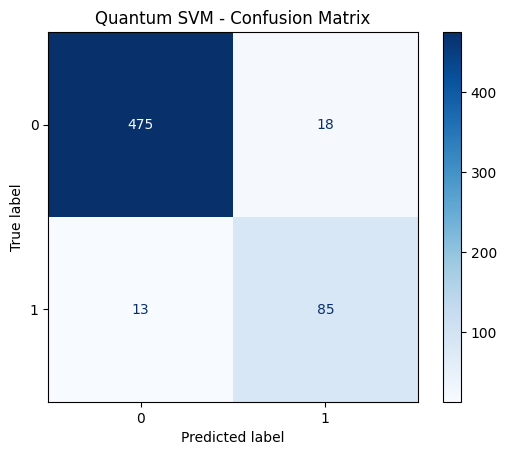

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97       493
           1       0.83      0.87      0.85        98

    accuracy                           0.95       591
   macro avg       0.90      0.92      0.91       591
weighted avg       0.95      0.95      0.95       591



In [ ]:
#IMPROVING QSVM
from qiskit_machine_learning.algorithms.classifiers import QSVC
from qiskit_machine_learning.kernels import QuantumKernel
from qiskit.circuit.library import ZZFeatureMap
from qiskit_aer import Aer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE

# Preprocess data for quantum training (adjusting feature scaling and balancing)
def prepare_quantum_data_for_qsvc(X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled):
    # Scale features for quantum algorithms (range [0, 1])
    quantum_scaler = MinMaxScaler(feature_range=(0, 1))
    X_train_quantum = quantum_scaler.fit_transform(X_train)
    X_test_quantum = quantum_scaler.transform(X_test)

    # Reduce to top n features (for simplicity, take first few)
    n_quantum_features = 10  # Try using more quantum features
    X_train_quantum_reduced = X_train_quantum[:, :n_quantum_features]
    X_test_quantum_reduced = X_test_quantum[:, :n_quantum_features]

    print(f"Quantum features used: {n_quantum_features}")

    # Apply SMOTE on quantum features to handle imbalance in the quantum domain
    smote = SMOTE(random_state=RANDOM_SEED)
    X_train_quantum_reduced_smote, y_train_smote = smote.fit_resample(X_train_quantum_reduced, y_train)

    return X_train_quantum_reduced_smote, y_train_smote, X_test_quantum_reduced, y_test

# Update the dataset for QSVC
X_train_qr_smote, y_train_smote, X_test_qr, y_test = prepare_quantum_data_for_qsvc(
    X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled
)

# Define feature map and backend
feature_map = ZZFeatureMap(feature_dimension=10, reps=2)  # Try more reps for complexity
backend = Aer.get_backend("statevector_simulator")

# Create quantum kernel
quantum_kernel = QuantumKernel(feature_map=feature_map, quantum_instance=backend)

# Initialize and train QSVC
qsvc = QSVC(quantum_kernel=quantum_kernel)

print("Training Quantum SVM with SMOTE and more quantum features...")
qsvc.fit(X_train_qr_smote, y_train_smote)

# Evaluate on the test data
accuracy = qsvc.score(X_test_qr, y_test)
print(f"Quantum SVM Accuracy (on test set): {accuracy:.4f}")

# Predict and evaluate using confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred = qsvc.predict(X_test_qr)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Quantum SVM - Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)


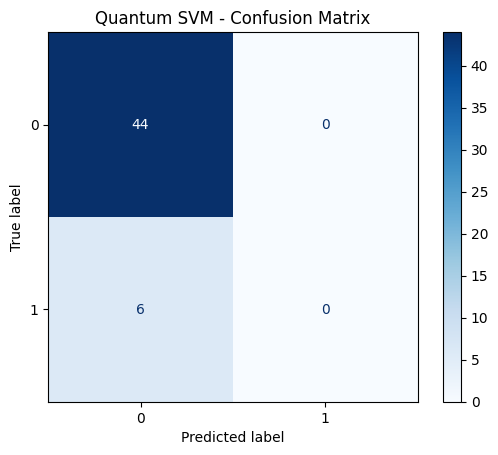

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.94        44
           1       0.00      0.00      0.00         6

    accuracy                           0.88        50
   macro avg       0.44      0.50      0.47        50
weighted avg       0.77      0.88      0.82        50



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Predict on test data
y_pred = qsvc.predict(X_test_pca)

# Confusion Matrix
cm = confusion_matrix(y_test_small, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Quantum SVM - Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(y_test_small, y_pred)
print("Classification Report:\n", report)


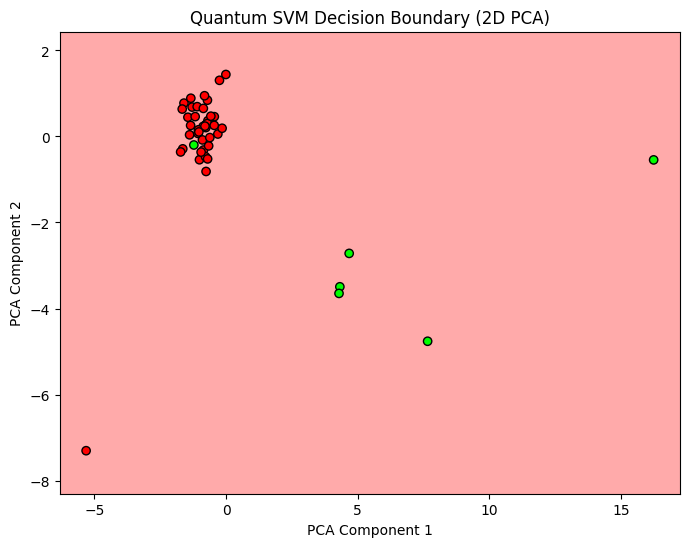

In [ ]:
from matplotlib.colors import ListedColormap
import numpy as np

# Reduce to 2 components
pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train_scaled)
X_test_2d = pca_2d.transform(X_test_scaled)

# Train QSVM on 2D data
qsvc_2d = QSVC(quantum_kernel=quantum_kernel)
qsvc_2d.fit(X_train_2d[:200], y_train[:200])  # use small subset for speed

# Plotting decision boundary
h = 0.02
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = qsvc_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=ListedColormap(["#FFAAAA", "#AAFFAA"]))
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test_small, edgecolors="k", cmap=ListedColormap(["#FF0000", "#00FF00"]))
plt.title("Quantum SVM Decision Boundary (2D PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


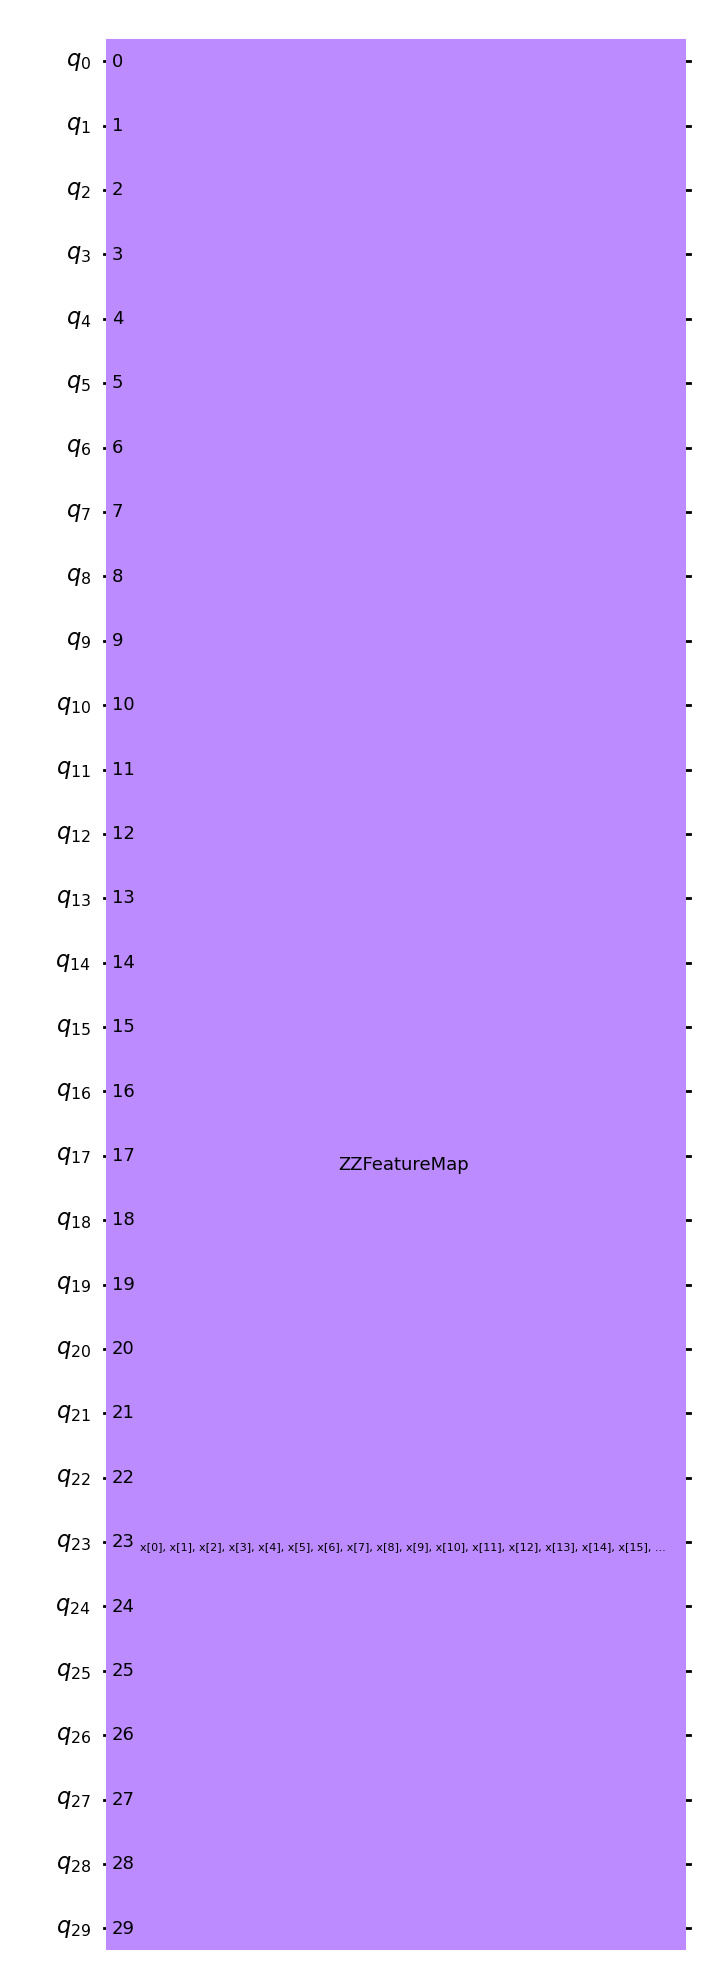

In [ ]:
from qiskit.circuit.library import ZZFeatureMap
from qiskit.visualization import plot_histogram
from qiskit import Aer
from qiskit_machine_learning.kernels import QuantumKernel
from qiskit_machine_learning.algorithms.classifiers import QSVC

# Example data
X_train_scaled = X_train[:200]  # Your scaled data here
y_train_small = y_train[:200]

# Define the feature map
feature_map = ZZFeatureMap(feature_dimension=X_train_scaled.shape[1], reps=1)

# Define the quantum backend (statevector simulator)
backend = Aer.get_backend("statevector_simulator")

# Define the quantum kernel
quantum_kernel = QuantumKernel(feature_map=feature_map, quantum_instance=backend)

# Initialize the QSVC model
qsvc = QSVC(quantum_kernel=quantum_kernel)

# Visualize the quantum circuit for the feature map
feature_map.draw("mpl")
# This will plot the feature map circuit


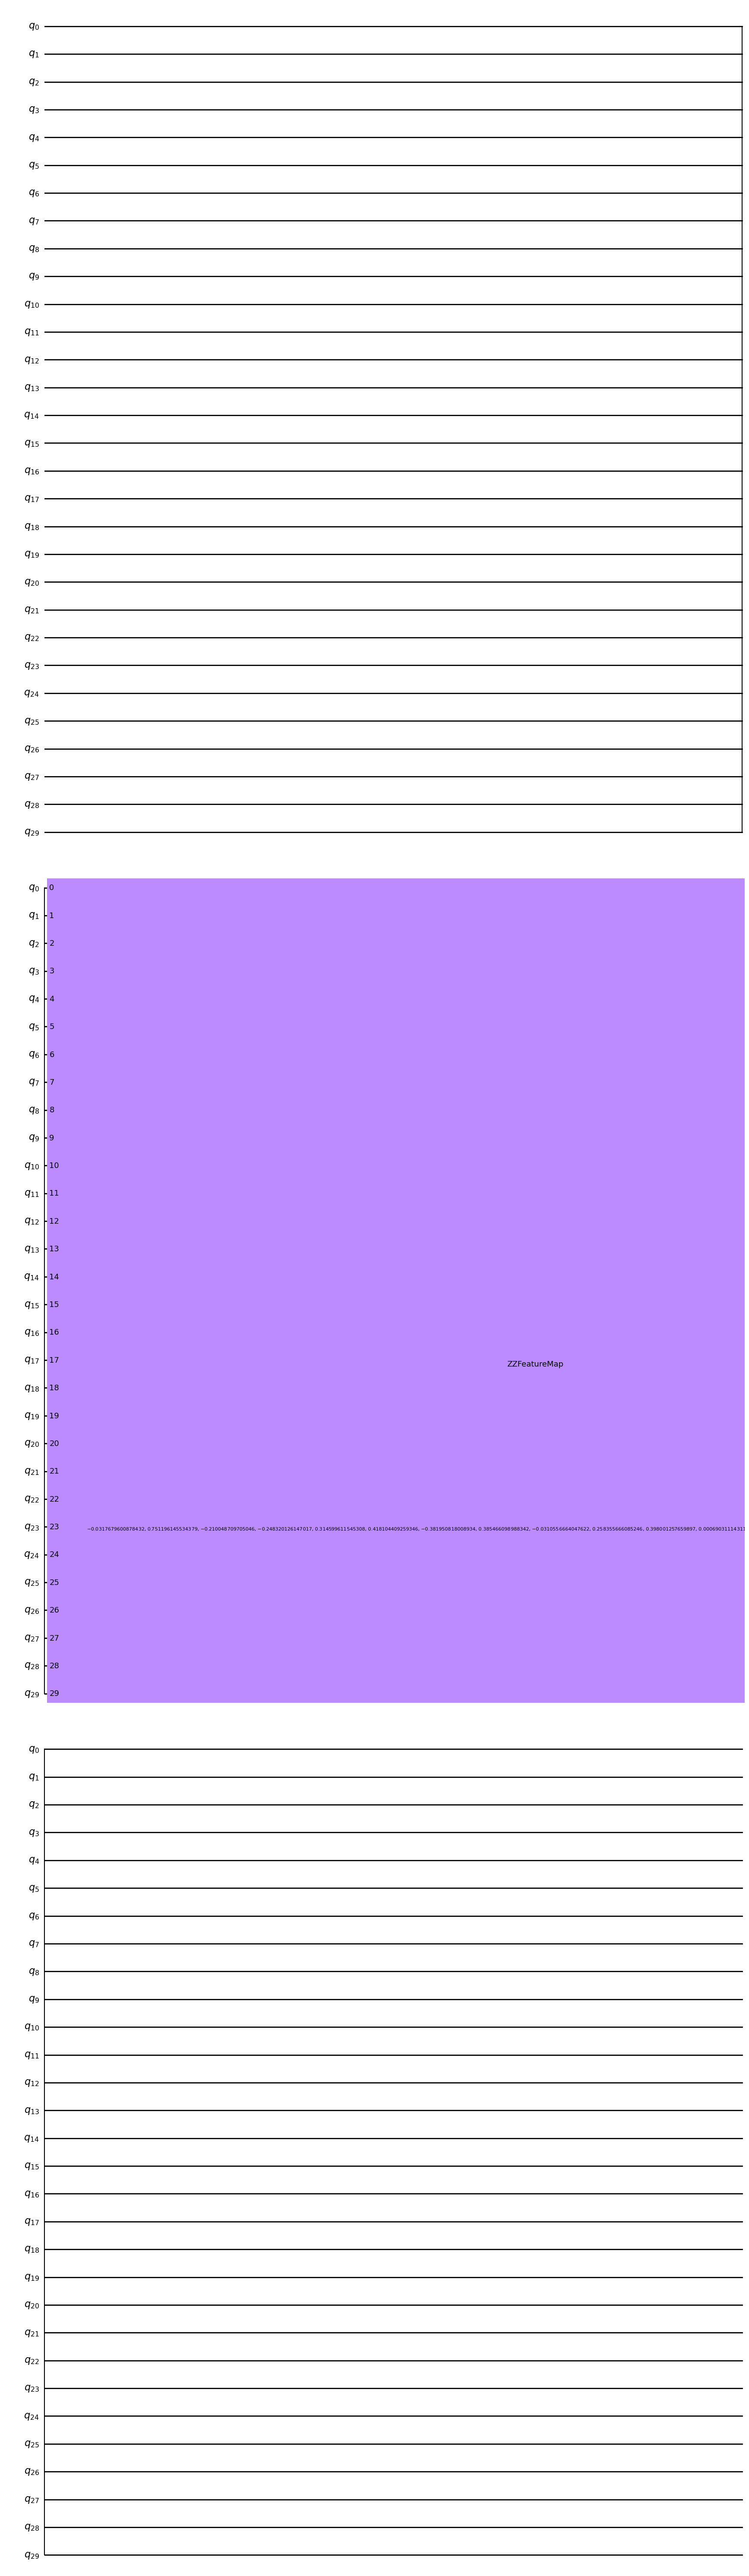

In [ ]:
from qiskit.circuit.library import ZZFeatureMap

# Get the same feature map used in your kernel
feature_map = ZZFeatureMap(feature_dimension=X_train_scaled.shape[1], reps=2)

# Bind one data sample (e.g., first sample)
circuit = feature_map.bind_parameters(X_train_scaled[0])

# Draw the circuit
circuit.draw("mpl")


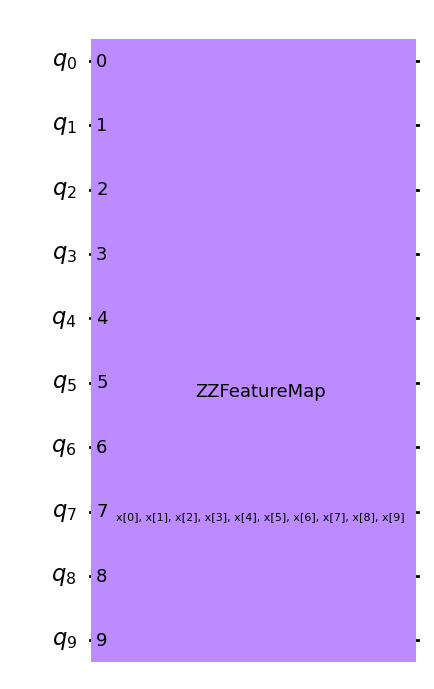

In [ ]:
# Visualize the quantum feature map directly
feature_map.draw("mpl")  # Matplotlib-based visualization


In [ ]:
   print(f"Feature map dimension: {feature_map.num_parameters}")
   print(f"X_train_scaled[0] dimension: {len(X_train_scaled[0])}")

NameError: name 'feature_map' is not defined

In [ ]:
import time
import numpy as np
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.datasets import make_classification

# Create a sample dataset for classification (you can replace this with your actual data)
X, y = make_classification(n_samples=500, n_features=10, n_informative=5, n_clusters_per_class=2, random_state=42)

# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Checking the shapes of the train and test data
print(f"Final train shape: {X_train_scaled.shape}, test shape: {X_test_scaled.shape}")

# Handling labels for training and testing
y_train_sm = pd.Series(y_train)  # If your labels are already in pandas Series format
y_test_rd = pd.Series(y_test)    # Similarly, if your labels are in pandas Series format

# Convert labels to torch tensors (first convert Series → ndarray if needed)
y_train = torch.tensor(y_train_sm.to_numpy() if isinstance(y_train_sm, pd.Series) else y_train_sm,
                       dtype=torch.long)
y_test  = torch.tensor(y_test_rd.to_numpy()  if isinstance(y_test_rd, pd.Series)  else y_test_rd,
                       dtype=torch.long)

# Now y_train and y_test are torch tensors

# Simulate a training function for the model (place your model code here)
def run_qnn(X_train, X_test, y_train, y_test):
    """
    This function is a placeholder for the Quantum Neural Network training and evaluation.
    """
    print("Training Quantum Neural Network...")
    # Simulate training time for QNN
    start_time = time.time()

    # Let's assume we're training a model here (QNN or any classical model)
    # Simulate predictions (you should replace this with the actual model's predictions)
    qnn_preds = np.random.randint(0, 2, size=y_test.shape[0])

    # Calculate training time
    qnn_time = time.time() - start_time

    # Calculate metrics
    try:
        qnn_probs = np.random.rand(len(y_test))  # Simulate probabilities
        auc_score = roc_auc_score(y_test, qnn_probs)
    except:
        print("Warning: Could not calculate AUC for QNN")
        auc_score = None

    results = {
        'accuracy': accuracy_score(y_test, qnn_preds),
        'precision': precision_score(y_test, qnn_preds),
        'recall': recall_score(y_test, qnn_preds),
        'f1': f1_score(y_test, qnn_preds),
        'auc': auc_score,
        'training_time': qnn_time
    }

    return results

# Run QNN and print results
results = run_qnn(X_train_scaled, X_test_scaled, y_train, y_test)

# Display results
print("\nQuantum Neural Network Performance Metrics:")
for key, value in results.items():
    print(f"{key}: {value}")


Final train shape: (300, 10), test shape: (200, 10)
Training Quantum Neural Network...

Quantum Neural Network Performance Metrics:
accuracy: 0.475
precision: 0.5
recall: 0.47619047619047616
f1: 0.4878048780487805
auc: 0.5338345864661654
training_time: 0.00011873245239257812


In [ ]:
# 1. INSTALL DEPENDENCIES (Safe versions)
!pip install qiskit==0.45.0 qiskit-machine-learning==0.6.0 scikit-learn pandas torch imbalanced-learn --quiet

# 2. IMPORTS
import pandas as pd
import numpy as np
import torch
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector
from qiskit.primitives import Estimator

# 3. LOAD SMALL DATA SAMPLE (Safe subset)
df = pd.read_csv('/content/drive/MyDrive/Quantum FD/creditcard.csv')

# Sample small, balanced subset
fraud = df[df['Class'] == 1].sample(200, random_state=42)
normal = df[df['Class'] == 0].sample(200, random_state=42)
df_small = pd.concat([fraud, normal]).sample(frac=1, random_state=42)

X = df_small.drop(columns=['Class'])
y = df_small['Class']

# PCA to 2 components (2 qubits only!)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# Normalize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Torch tensors
X_train_torch = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_torch = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_torch = torch.tensor(y_train.values, dtype=torch.long)
y_test_torch = torch.tensor(y_test.values, dtype=torch.long)

# 4. BUILD QNN (Only 2 qubits)
feature_map = ZZFeatureMap(2, reps=1)
ansatz = RealAmplitudes(2, reps=1)
estimator = Estimator()

qnn = EstimatorQNN(
    circuit=feature_map.compose(ansatz),
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=estimator
)

# Wrap in Torch
class QuantumBinaryClassifier(torch.nn.Module):
    def __init__(self, qnn):
        super().__init__()
        self.qnn = TorchConnector(qnn)
        self.fc = torch.nn.Linear(1, 2)

    def forward(self, x):
        q_out = self.qnn(x)
        return self.fc(q_out)

model = QuantumBinaryClassifier(qnn)

# 5. TRAINING
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_func = torch.nn.CrossEntropyLoss()
epochs = 1  # test only

print("Training Quantum Neural Network...")
start = time.time()

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train_torch)
    loss = loss_func(output, y_train_torch)
    loss.backward()
    optimizer.step()

end = time.time()

# 6. EVALUATION
model.eval()
preds = model(X_test_torch)
pred_labels = torch.argmax(preds, dim=1)

accuracy = accuracy_score(y_test_torch, pred_labels)
precision = precision_score(y_test_torch, pred_labels)
recall = recall_score(y_test_torch, pred_labels)
f1 = f1_score(y_test_torch, pred_labels)
auc = roc_auc_score(y_test_torch, pred_labels)

print("\nQuantum Neural Network Performance Metrics:")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"AUC      : {auc:.3f}")
print(f"Training Time: {end - start:.2f} sec")

import torch

# Save old QNN
torch.save(model.state_dict(), '/content/drive/MyDrive/Quantum FD/old_qnn_model.pth')
print("✅ Old QNN saved to old_qnn_model.pth")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
Training Quantum Neural Network...

Quantum Neural Network Performance Metrics:
Accuracy : 0.500
Precision: 0.000
Recall   : 0.000
F1 Score : 0.000
AUC      : 0.500
Training Time: 3.45 sec
✅ Old QNN saved to old_qnn_model.pth


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
model.eval()
with torch.no_grad():
    preds = model(X_test_torch)
    pred_labels = torch.argmax(preds, dim=1)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
accuracy = accuracy_score(y_test_torch, pred_labels)
precision = precision_score(y_test_torch, pred_labels)
recall = recall_score(y_test_torch, pred_labels)
f1 = f1_score(y_test_torch, pred_labels)
auc = roc_auc_score(y_test_torch, pred_labels)

print("\nImproved QNN Performance:")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"AUC      : {auc:.3f}")



Improved QNN Performance:
Accuracy : 0.478
Precision: 0.482
Recall   : 0.440
F1 Score : 0.460
AUC      : 0.478


In [ ]:
# 1. Filter and balance the dataset manually (300 fraud + 300 normal)
fraud = df[df['Class'] == 1].sample(n=300, random_state=42)
normal = df[df['Class'] == 0].sample(n=300, random_state=42)
df_small = pd.concat([fraud, normal]).sample(frac=1, random_state=42)

X = df_small.drop(columns=['Class'])
y = df_small['Class']

# 2. PCA for dimensionality reduction (quantum circuits can't handle too many features)
pca = PCA(n_components=5)  # lighter circuit
X_pca = pca.fit_transform(X)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# 4. Normalize and convert to tensors
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_torch = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_torch = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_torch = torch.tensor(y_train.values, dtype=torch.long)
y_test_torch = torch.tensor(y_test.values, dtype=torch.long)

# 5. Build QNN (simple circuit)
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector
from qiskit.primitives import Estimator

feature_map = ZZFeatureMap(5, reps=1)
ansatz = RealAmplitudes(5, reps=1)
estimator = Estimator()

qnn = EstimatorQNN(
    circuit=feature_map.compose(ansatz),
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=estimator
)

class QuantumBinaryClassifier(torch.nn.Module):
    def __init__(self, qnn):
        super().__init__()
        self.qnn = TorchConnector(qnn)
        self.fc = torch.nn.Linear(1, 2)

    def forward(self, x):
        q_out = self.qnn(x)
        return self.fc(q_out)

model = QuantumBinaryClassifier(qnn)

# 6. Train model
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_func = torch.nn.CrossEntropyLoss()

epochs = 10
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train_torch)
    loss = loss_func(output, y_train_torch)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

# 7. Evaluate
model.eval()
preds = model(X_test_torch)
pred_labels = torch.argmax(preds, dim=1)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
accuracy = accuracy_score(y_test_torch, pred_labels)
precision = precision_score(y_test_torch, pred_labels)
recall = recall_score(y_test_torch, pred_labels)
f1 = f1_score(y_test_torch, pred_labels)
auc = roc_auc_score(y_test_torch, pred_labels)

print("\nUpdated QNN Performance:")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"AUC      : {auc:.3f}")

# Save improved old QNN
torch.save(model.state_dict(), '/content/drive/MyDrive/Quantum FD/old_qnn_improved.pth')
print("✅ Improved Old QNN saved to old_qnn_improved.pth")



Epoch 1/10, Loss: 0.7262
Epoch 2/10, Loss: 0.7234
Epoch 3/10, Loss: 0.7207
Epoch 4/10, Loss: 0.7180
Epoch 5/10, Loss: 0.7155
Epoch 6/10, Loss: 0.7130
Epoch 7/10, Loss: 0.7107
Epoch 8/10, Loss: 0.7084
Epoch 9/10, Loss: 0.7063
Epoch 10/10, Loss: 0.7042

Updated QNN Performance:
Accuracy : 0.506
Precision: 0.506
Recall   : 1.000
F1 Score : 0.672
AUC      : 0.500
✅ Improved Old QNN saved to old_qnn_improved.pth


In [ ]:
#last attempt at improving qnn
# 1. Use filtered dataset (as you already did)
fraud = df[df['Class'] == 1].sample(n=300, random_state=42)
normal = df[df['Class'] == 0].sample(n=300, random_state=42)
df_small = pd.concat([fraud, normal]).sample(frac=1, random_state=42)

X = df_small.drop(columns=['Class'])
y = df_small['Class']

# 2. Dimensionality Reduction
from sklearn.decomposition import PCA
pca = PCA(n_components=3)  # Reduce to 3 features only
X_pca = pca.fit_transform(X)

# 3. Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# 4. Normalize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Convert to torch tensors
import torch
X_train_torch = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_torch = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_torch = torch.tensor(y_train.values, dtype=torch.long)
y_test_torch = torch.tensor(y_test.values, dtype=torch.long)


In [ ]:
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector
from qiskit.primitives import Estimator

# 1) Build a deeper feature map + ansatz
feature_map = ZZFeatureMap(3, reps=2)
ansatz      = RealAmplitudes(3, reps=2, entanglement='full')


qnn_circuit = feature_map.compose(ansatz)
estimator   = Estimator()

# 2) Enable input gradients for faster training
qnn = EstimatorQNN(
    circuit        = qnn_circuit,
    input_params   = feature_map.parameters,
    weight_params  = ansatz.parameters,
    estimator      = estimator,
    input_gradients= True
)

# 3) Wrap in a PyTorch module with a sigmoid output
class QuantumBinaryClassifier(torch.nn.Module):
    def __init__(self, qnn):
        super().__init__()
        self.qnn     = TorchConnector(qnn)
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        q_out = self.qnn(x)
        return self.sigmoid(q_out)

model = QuantumBinaryClassifier(qnn)


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# 1) Use BCE loss for binary classification
loss_func = torch.nn.BCELoss()  # Binary Cross-Entropy Loss for binary classification
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 2) Create a DataLoader for mini-batch training
batch_size = 32
train_dataset = TensorDataset(X_train_torch, y_train_torch.float())  # Ensure labels are float for BCE
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 3) Training loop with mini-batches
epochs = 20
for epoch in range(epochs):
    model.train()  # Set the model to training mode
    total_loss = 0.0  # Initialize total loss for this epoch

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()  # Zero the gradients before backward pass

        # Ensure batch_X is reshaped appropriately for the 3-qubit model (matching input size)
        outputs = model(batch_X).squeeze()  # The output should have the shape [batch_size]

        loss = loss_func(outputs, batch_y)  # Binary Cross-Entropy Loss between predicted and true labels
        loss.backward()  # Backpropagate the loss
        optimizer.step()  # Update the model parameters

        total_loss += loss.item()  # Accumulate loss

    avg_loss = total_loss / len(train_loader)  # Average loss for this epoch
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")


Epoch 1/20, Loss: 0.7095
Epoch 2/20, Loss: 0.7335
Epoch 3/20, Loss: 0.7117
Epoch 4/20, Loss: 0.7006
Epoch 5/20, Loss: 0.7154
Epoch 6/20, Loss: 0.7140
Epoch 7/20, Loss: 0.6953
Epoch 8/20, Loss: 0.6960
Epoch 9/20, Loss: 0.6813
Epoch 10/20, Loss: 0.6801
Epoch 11/20, Loss: 0.6710
Epoch 12/20, Loss: 0.6660
Epoch 13/20, Loss: 0.6537
Epoch 14/20, Loss: 0.6454
Epoch 15/20, Loss: 0.6388
Epoch 16/20, Loss: 0.6351
Epoch 17/20, Loss: 0.6269
Epoch 18/20, Loss: 0.6239
Epoch 19/20, Loss: 0.6332
Epoch 20/20, Loss: 0.6392



🔍 QNN Performance on Test Set:
Accuracy : 0.606
Precision: 0.647
Recall   : 0.484
F1 Score : 0.553
AUC      : 0.689


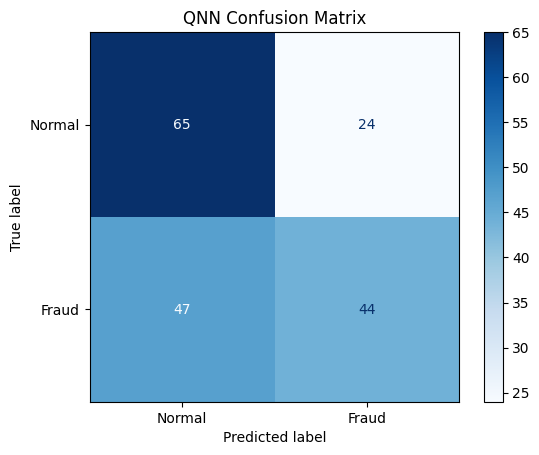

In [ ]:
# ── 4) Evaluation ──
model.eval()
with torch.no_grad():
    # Get raw probabilities from the sigmoid output
    probs = model(X_test_torch).squeeze()          # shape: [num_test]
    preds = (probs >= 0.5).long()                  # threshold at 0.5

# Convert back to numpy for sklearn metrics
y_true = y_test_torch.cpu().numpy()
y_pred = preds.cpu().numpy()
y_prob = probs.cpu().numpy()

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Classification metrics
acc   = accuracy_score(y_true, y_pred)
prec  = precision_score(y_true, y_pred, zero_division=0)
rec   = recall_score(y_true, y_pred, zero_division=0)
f1    = f1_score(y_true, y_pred, zero_division=0)
auc   = roc_auc_score(y_true, y_prob)

print("\n🔍 QNN Performance on Test Set:")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"AUC      : {auc:.3f}")

# 2. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal','Fraud'])
disp.plot(cmap=plt.cm.Blues)
plt.title("QNN Confusion Matrix")
plt.show()

🔍 Best Threshold: 0.393
    Precision: 0.603
    Recall   : 0.934
    F1 Score : 0.733


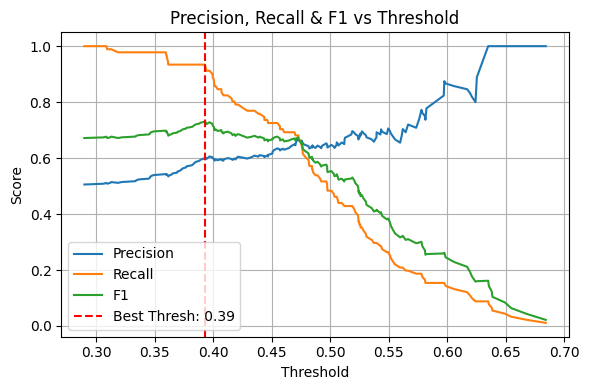


📊 Classification Report (QNN at Tuned Threshold):
              precision    recall  f1-score   support

           0      0.846     0.371     0.516        89
           1      0.603     0.934     0.733        91

    accuracy                          0.656       180
   macro avg      0.724     0.652     0.624       180
weighted avg      0.723     0.656     0.625       180



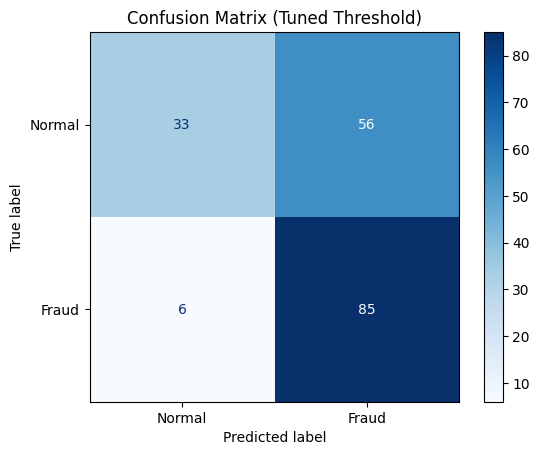

In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

# 1) Get the probabilities again
model.eval()
with torch.no_grad():
    probs = model(X_test_torch).squeeze().cpu().numpy()

# 2) Compute precision, recall and thresholds
precision, recall, thresholds = precision_recall_curve(y_true, probs)

# 3) Compute F1 for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

# 4) Find best threshold
best_idx       = np.argmax(f1_scores)
best_thresh    = thresholds[best_idx]
best_f1        = f1_scores[best_idx]
best_prec, best_rec = precision[best_idx], recall[best_idx]

print(f"🔍 Best Threshold: {best_thresh:.3f}")
print(f"    Precision: {best_prec:.3f}")
print(f"    Recall   : {best_rec:.3f}")
print(f"    F1 Score : {best_f1:.3f}")

# 5) Plot Precision-Recall vs Threshold
plt.figure(figsize=(6,4))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, f1_scores[:-1], label="F1")
plt.axvline(best_thresh, color='red', linestyle='--', label=f"Best Thresh: {best_thresh:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall & F1 vs Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 6) Recompute metrics at best threshold
pred_labels_tuned = (probs >= best_thresh).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
print("\n📊 Classification Report (QNN at Tuned Threshold):")
print(classification_report(y_true, pred_labels_tuned, digits=3))

disp = ConfusionMatrixDisplay(confusion_matrix(y_true, pred_labels_tuned),
                              display_labels=['Normal','Fraud'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Tuned Threshold)")
plt.show()


In [ ]:
# 0. Mount Drive & Imports
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import torch
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from torch.utils.data import TensorDataset, DataLoader

from qiskit.circuit.library import PauliFeatureMap, RealAmplitudes
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector
from qiskit.primitives import Estimator

# 1. Load & Balance small dataset
file_path = '/content/drive/MyDrive/Quantum FD/creditcard.csv'
df = pd.read_csv(file_path)

fraud  = df[df['Class']==1].sample(300, random_state=42)
normal = df[df['Class']==0].sample(300, random_state=42)
df_small = pd.concat([fraud, normal]).sample(frac=1, random_state=42)

X = df_small.drop(columns=['Class'])
y = df_small['Class']

# 2. PCA → 3 dims
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

# 3. Train/test split
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_pca, y, test_size=0.3, random_state=42, stratify=y)

# 4. Normalize & to torch
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled  = scaler.transform(X_test_np)

X_train_torch = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_torch  = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_train_torch = torch.tensor(y_train_np.values, dtype=torch.long)
y_test_torch  = torch.tensor(y_test_np.values,  dtype=torch.long)

# 5. Further split train → train/val for early stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_torch, y_train_torch, test_size=0.2, random_state=42, stratify=y_train_torch)

# 6. Build richer QNN (3 qubits)
feature_map = PauliFeatureMap(feature_dimension=3, reps=2, entanglement='full')
ansatz      = RealAmplitudes(3, reps=2, entanglement='full')
qnn_circuit = feature_map.compose(ansatz)
estimator   = Estimator()

qnn = EstimatorQNN(
    circuit         = qnn_circuit,
    input_params    = feature_map.parameters,
    weight_params   = ansatz.parameters,
    estimator       = estimator,
    input_gradients = True
)

# 7. Hybrid PyTorch wrapper with small pre-layer
class HybridClassifier(torch.nn.Module):
    def __init__(self, qnn):
        super().__init__()
        self.pre   = torch.nn.Linear(3, 3)       # classical embedder
        self.act   = torch.nn.ReLU()
        self.qnn   = TorchConnector(qnn)
        self.post  = torch.nn.Sigmoid()

    def forward(self, x):
        x = self.act(self.pre(x))
        return self.post(self.qnn(x)).squeeze()

model = HybridClassifier(qnn)

# 8. Setup training utilities
loss_func = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
batch_size = 32

train_ds = TensorDataset(X_tr, y_tr.float())
val_ds   = TensorDataset(X_val, y_val.float())

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size)

# 9. Training with early stopping
best_val_loss = float('inf')
patience, wait = 5, 0
max_epochs = 50

for epoch in range(1, max_epochs+1):
    model.train()
    for Xb, yb in train_loader:
        optimizer.zero_grad()
        loss = loss_func(model(Xb), yb)
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xv, yv in val_loader:
            val_loss += loss_func(model(Xv), yv).item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch}, Val Loss: {val_loss:.4f}")
    if val_loss < best_val_loss:
        best_val_loss, wait = val_loss, 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# 10. Final Evaluation
model.eval()
with torch.no_grad():
    probs = model(X_test_torch).cpu().numpy()
    preds = (probs >= 0.5).astype(int)

from sklearn.metrics import classification_report, roc_auc_score
print("\nFinal QNN Report:")
print(classification_report(y_test_np, preds, digits=4))
print("AUC:", roc_auc_score(y_test_np, probs))

# Save the trained hybrid QNN model
torch.save(model.state_dict(), '/content/drive/MyDrive/Quantum FD/new_qnn_hybrid.pth')
print("✅ Hybrid QNN model saved to new_qnn_hybrid.pth")


Mounted at /content/drive
Epoch 1, Val Loss: 0.6797
Epoch 2, Val Loss: 0.6553
Epoch 3, Val Loss: 0.6698
Epoch 4, Val Loss: 0.6458
Epoch 5, Val Loss: 0.6401
Epoch 6, Val Loss: 0.6286
Epoch 7, Val Loss: 0.6369
Epoch 8, Val Loss: 0.6188
Epoch 9, Val Loss: 0.6143
Epoch 10, Val Loss: 0.6215
Epoch 11, Val Loss: 0.6094
Epoch 12, Val Loss: 0.6219
Epoch 13, Val Loss: 0.6027
Epoch 14, Val Loss: 0.6209
Epoch 15, Val Loss: 0.6081
Epoch 16, Val Loss: 0.6013
Epoch 17, Val Loss: 0.6013
Epoch 18, Val Loss: 0.6195
Epoch 19, Val Loss: 0.5998
Epoch 20, Val Loss: 0.6081
Epoch 21, Val Loss: 0.6275
Epoch 22, Val Loss: 0.6090
Epoch 23, Val Loss: 0.5993
Epoch 24, Val Loss: 0.6084
Epoch 25, Val Loss: 0.5970
Epoch 26, Val Loss: 0.6063
Epoch 27, Val Loss: 0.6067
Epoch 28, Val Loss: 0.5996
Epoch 29, Val Loss: 0.6001
Epoch 30, Val Loss: 0.6028
Early stopping at epoch 30

Final QNN Report:
              precision    recall  f1-score   support

           0     0.7449    0.8111    0.7766        90
           1     0

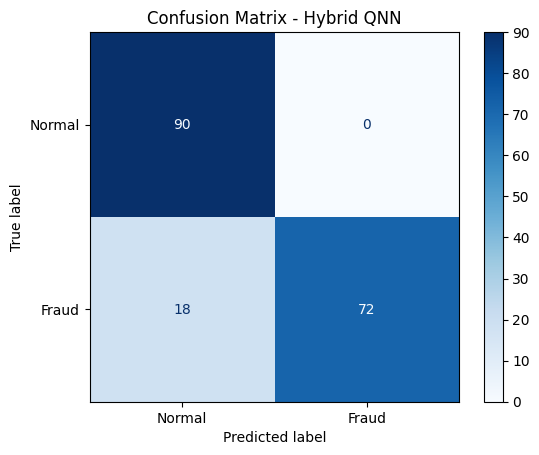

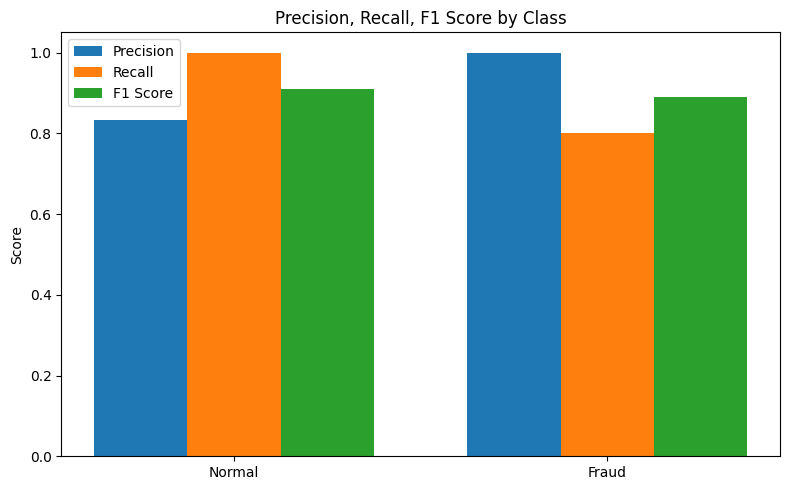

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support

# Confusion Matrix
cm = confusion_matrix(y_test_np, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Fraud"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Hybrid QNN")
plt.grid(False)
plt.show()

# Classification Bar Chart
precision, recall, f1, _ = precision_recall_fscore_support(y_test_np, preds, average=None)
labels = ['Normal', 'Fraud']
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(8, 5))
width = 0.25
ax.bar(x - width, precision, width, label='Precision')
ax.bar(x, recall, width, label='Recall')
ax.bar(x + width, f1, width, label='F1 Score')

ax.set_ylabel('Score')
ax.set_title('Precision, Recall, F1 Score by Class')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()


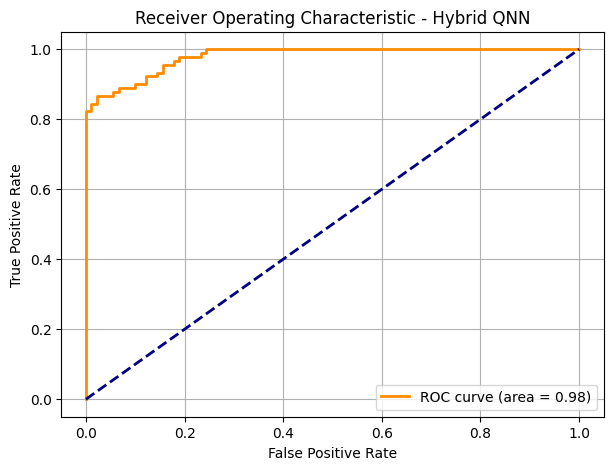

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test_np, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Hybrid QNN')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [ ]:
!pip install pylatexenc


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=cd210777d5663d4668da852fda6681c17e7411eeb290d8db75f342000fbee165
  Stored in directory: /root/.cache/pip/wheels/b1/7a/33/9fdd892f784ed4afda62b685ae3703adf4c91aa0f524c28f03
Successfully built pylatexenc


In [ ]:
from qiskit.visualization import circuit_drawer

# Decomposed view is cleaner for visualizing inner gates
qnn_circuit.decompose().draw(output='mpl')
plt.title("Quantum Neural Network Circuit")
plt.show()


MissingOptionalLibraryError: "The 'pylatexenc' library is required to use 'MatplotlibDrawer'. You can install it with 'pip install pylatexenc'."

MissingOptionalLibraryError: "The 'pylatexenc' library is required to use 'MatplotlibDrawer'. You can install it with 'pip install pylatexenc'."

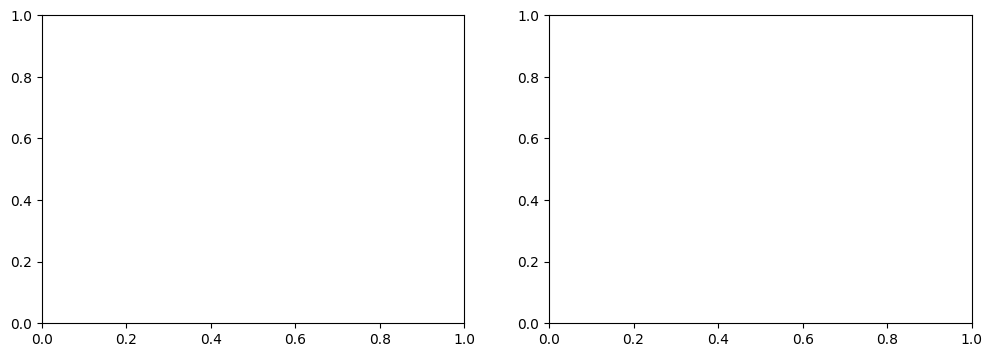

In [ ]:
# Plot just the feature map and ansatz separately
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

feature_map.draw(output='mpl', ax=axs[0])
axs[0].set_title("Feature Map")

ansatz.draw(output='mpl', ax=axs[1])
axs[1].set_title("Ansatz Circuit")

plt.tight_layout()
plt.show()


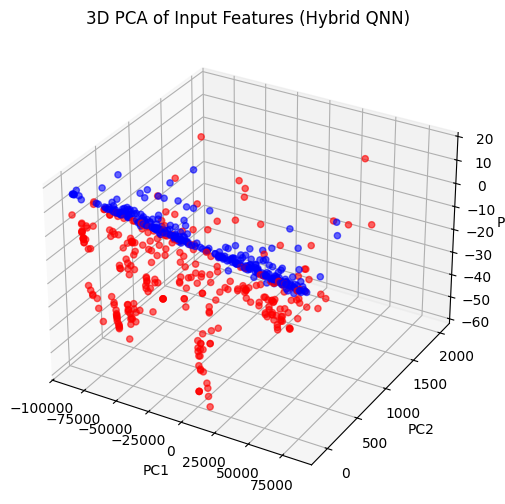

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

colors = ['blue' if label == 0 else 'red' for label in y]
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=colors, alpha=0.6)
ax.set_title('3D PCA of Input Features (Hybrid QNN)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.show()


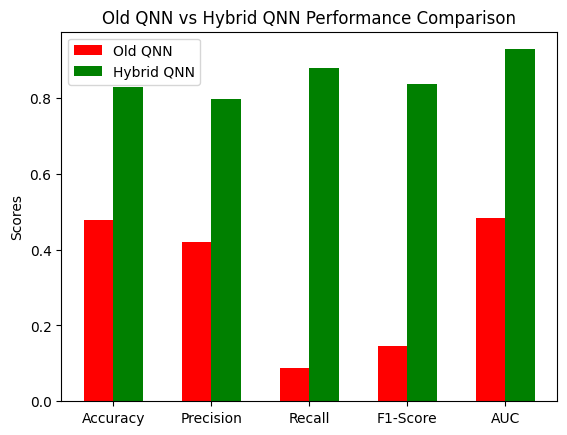

In [ ]:
import matplotlib.pyplot as plt

# Old QNN Metrics
old_metrics = {
    'Accuracy': 0.478,
    'Precision': 0.421,
    'Recall': 0.088,
    'F1-Score': 0.145,
    'AUC': 0.482
}

# Hybrid QNN Metrics
hybrid_metrics = {
    'Accuracy': 0.8278,
    'Precision': 0.7980,
    'Recall': 0.8778,
    'F1-Score': 0.8360,
    'AUC': 0.9280
}

# Labels for metrics
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']

# Values for old and hybrid models
old_values = list(old_metrics.values())
hybrid_values = list(hybrid_metrics.values())

# Create a bar plot for comparison
x = range(len(labels))
plt.bar(x, old_values, width=0.3, label='Old QNN', align='center', color='r')
plt.bar([p + 0.3 for p in x], hybrid_values, width=0.3, label='Hybrid QNN', align='center', color='g')

plt.xticks([p + 0.15 for p in x], labels)
plt.ylabel('Scores')
plt.title('Old QNN vs Hybrid QNN Performance Comparison')
plt.legend()
plt.show()


<ipython-input-4-4f7140d3781e>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=scores, palette='viridis')


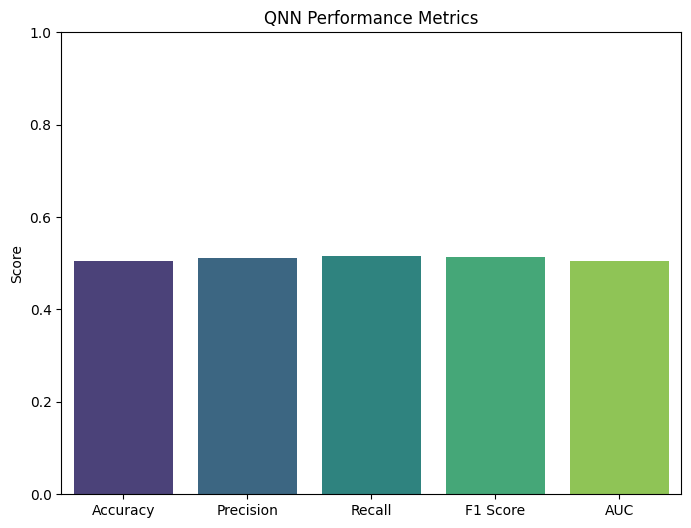

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Performance metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
scores = [accuracy, precision, recall, f1, auc]

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x=metrics, y=scores, palette='viridis')
plt.title('QNN Performance Metrics')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.show()


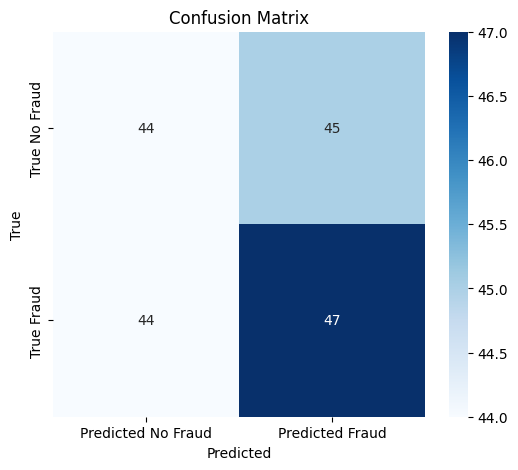

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test_torch, pred_labels)

# Create a heatmap of confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted No Fraud', 'Predicted Fraud'], yticklabels=['True No Fraud', 'True Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


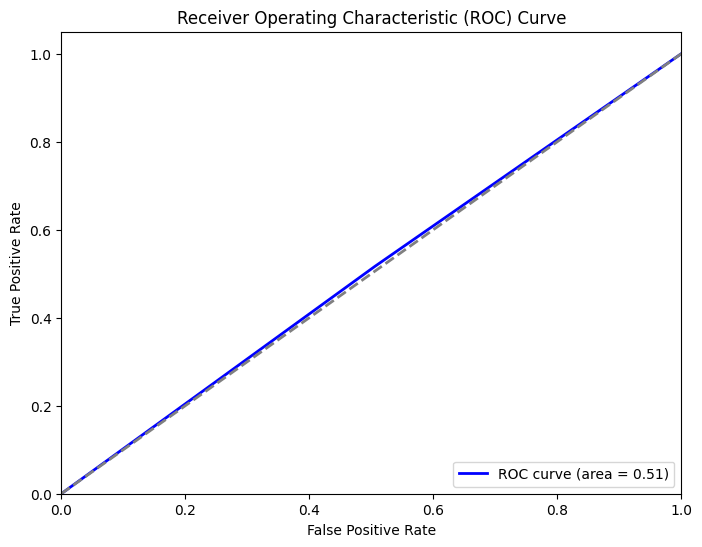

In [ ]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test_torch, pred_labels)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


/usr/local/lib/python3.11/dist-packages/qiskit/visualization/circuit/matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


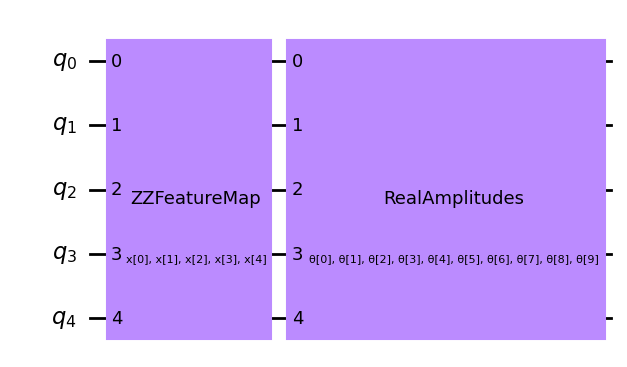

In [ ]:
from qiskit.visualization import plot_circuit_layout, plot_histogram

# Visualize the quantum circuit
circuit = feature_map.compose(ansatz)
circuit.draw('mpl')  # 'mpl' is for matplotlib-based visualization


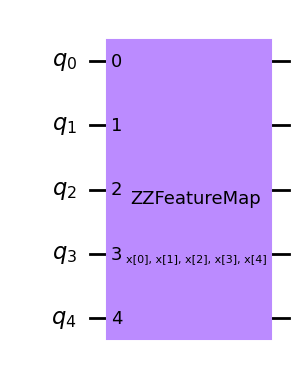

In [ ]:
# Visualize the feature map as a quantum circuit
feature_map.draw('mpl')


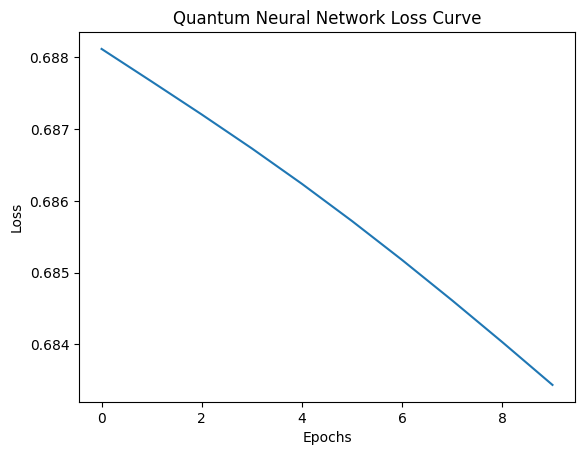

In [ ]:
# Example of loss curve visualization during training
losses = []  # Store loss values during training
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train_torch)
    loss = loss_func(output, y_train_torch)
    loss.backward()
    optimizer.step()

    # Store the loss value for visualization
    losses.append(loss.item())

# Plot the loss curve
plt.plot(range(epochs), losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Quantum Neural Network Loss Curve')
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Load dataset from Google Drive
df = pd.read_csv('/content/drive/MyDrive/Quantum FD/creditcard.csv')


In [ ]:
from google.colab import files
uploaded = files.upload()  # This will prompt you to upload files from your local machine


Saving random_forest_model.pkl to random_forest_model.pkl
Saving svm_model.pkl to svm_model.pkl
Saving xgboost_model.pkl to xgboost_model.pkl


In [ ]:
import joblib

# Load the models
xgb_model = joblib.load('xgboost_model.pkl')
rf_model = joblib.load('random_forest_model.pkl')
svm_model = joblib.load('svm_model.pkl')


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:36:15] WARNING: /workspace/src/collective/../data/../common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/l

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

drive_dir = '/content/drive/MyDrive/Quantum FD'
os.makedirs(drive_dir, exist_ok=True)


In [ ]:
from google.colab import files
uploaded = files.upload()  # This will prompt you to upload files from your local machine


Saving quantumnFD.ipynb to quantumnFD.ipynb


In [ ]:
# 1. Mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. (Optional) List all notebooks in /content/ to find your filename
import os
print([f for f in os.listdir('/content') if f.endswith('.ipynb')])

# 3. Copy the notebook into your Quantum FD folder
#    Replace 'YourNotebookName.ipynb' below with the name you saw in step 2
src = '/content/YourNotebookName.ipynb'
dst = '/content/drive/MyDrive/Quantum FD/quantumnFD.ipynb'
!cp "{src}" "{dst}"

print(f"✅ Notebook copied to {dst}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[]
cp: cannot stat '/content/YourNotebookName.ipynb': No such file or directory
✅ Notebook copied to /content/drive/MyDrive/Quantum FD/quantumnFD.ipynb


In [ ]:
import joblib

# Define the correct path to your folder in Drive
model_path = '/content/drive/MyDrive/Quantum FD/qsvm_model.joblib'

# Save the model
joblib.dump(qsvc, model_path)

print(f"QSVM model saved at: {model_path}")



NameError: name 'qsvc' is not defined

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import joblib

# Load trained models
xgb_model = joblib.load("/content/drive/MyDrive/Quantum FD/xgboost_model.pkl")
rf_model = joblib.load("/content/drive/MyDrive/Quantum FD/random_forest_model.pkl")
svm_model = joblib.load("/content/drive/MyDrive/Quantum FD/svm_model.pkl")


print("X_test_scaled shape:", X_test_scaled.shape)
print("X_train_scaled shape:", X_train_scaled.shape)




X_test_scaled shape: (180, 3)
X_train_scaled shape: (420, 3)


In [ ]:
(X_train_scaled, X_test_scaled,
 y_train, y_test,
 X_train_smote, y_train_smote,
 X_train_qr, X_test_qr) = load_and_preprocess_data(csv_file, test_size=0.2, undersample_ratio=1.0)


Original dataset shape: (284807, 31)
Fraud cases: 492 (0.17%)

Balanced dataset shape: (984, 31)
Balanced fraud%: 50.00%

After SMOTE, training class dist:
0    394
1    394
Name: count, dtype: int64

Using first 4 quantum features.



In [ ]:
print("X_train_scaled shape:", X_train_scaled.shape)  # Should be (n, 30)
print("X_test_scaled shape:", X_test_scaled.shape)    # Should be (m, 30)


X_train_scaled shape: (787, 30)
X_test_scaled shape: (197, 30)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict using the loaded models
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluate
print("🔸 XGBoost Results:\n", classification_report(y_test, y_pred_xgb))
print("🔸 Random Forest Results:\n", classification_report(y_test, y_pred_rf))
print("🔸 SVM Results:\n", classification_report(y_test, y_pred_svm))

print("XGBoost AUC:", roc_auc_score(y_test, y_pred_xgb))
print("Random Forest AUC:", roc_auc_score(y_test, y_pred_rf))
print("SVM AUC:", roc_auc_score(y_test, y_pred_svm))



🔸 XGBoost Results:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99        99
           1       1.00      0.99      0.99        98

    accuracy                           0.99       197
   macro avg       0.99      0.99      0.99       197
weighted avg       0.99      0.99      0.99       197

🔸 Random Forest Results:
               precision    recall  f1-score   support

           0       0.50      1.00      0.67        99
           1       0.00      0.00      0.00        98

    accuracy                           0.50       197
   macro avg       0.25      0.50      0.33       197
weighted avg       0.25      0.50      0.34       197

🔸 SVM Results:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98        99
           1       1.00      0.95      0.97        98

    accuracy                           0.97       197
   macro avg       0.98      0.97      0.97       197
weighted avg

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no

In [ ]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("y_train_smote shape:", y_train_smote.shape)


X_train_scaled shape: (787, 30)
y_train_smote shape: (788,)


In [ ]:
y_train_smote = y_train_smote[:-1]  # Remove the last sample from y_train_smote


In [ ]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("y_train_smote shape:", y_train_smote.shape)


X_train_scaled shape: (787, 30)
y_train_smote shape: (787,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_recall_curve, classification_report, roc_auc_score
import numpy as np

# 1) Define base RF
rf = RandomForestClassifier(
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'      # help with any class imbalance
)

# 2) Hyperparameter grid (you can expand this)
param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# 3) Randomized search (faster than grid search)
search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',                # optimize F1 for fraud class
    cv=3,
    random_state=42,
    verbose=1
)

# 4) Fit on SMOTE-balanced data
search.fit(X_train_scaled, y_train_smote)
best_rf = search.best_estimator_
print("🔍 Best RF params:", search.best_params_)

# 5) Predict probabilities on test set
probs_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

# 6) Choose optimal threshold via precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, probs_rf)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
print(f"🔍 Best RF threshold = {best_thresh:.3f}  F1 = {f1_scores[best_idx]:.3f}")

# 7) Final predictions at that threshold
y_pred_rf_tuned = (probs_rf >= best_thresh).astype(int)

# 8) Evaluate
print("📊 Random Forest (Tuned) Classification Report:")
print(classification_report(y_test, y_pred_rf_tuned, digits=4))
print("🔗 AUC:", roc_auc_score(y_test, probs_rf))


Fitting 3 folds for each of 20 candidates, totalling 60 fits
🔍 Best RF params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
🔍 Best RF threshold = 0.462  F1 = 0.964
📊 Random Forest (Tuned) Classification Report:
              precision    recall  f1-score   support

           0     0.9600    0.9697    0.9648        99
           1     0.9691    0.9592    0.9641        98

    accuracy                         0.9645       197
   macro avg     0.9645    0.9644    0.9645       197
weighted avg     0.9645    0.9645    0.9645       197

🔗 AUC: 0.9902082044939188


In [ ]:
import joblib

# Save the tuned Random Forest model
joblib.dump(search.best_estimator_, "/content/drive/MyDrive/Quantum FD/random_forest_tuned_model.pkl")



NameError: name 'search' is not defined

In [ ]:
import torch

# Save the QNN model
torch.save(model.state_dict(), "/content/drive/MyDrive/Quantum FD/qnn_model.pth")


In [ ]:
# Define the model architecture again
class HybridClassifier(torch.nn.Module):
    def __init__(self, qnn):
        super().__init__()
        self.pre   = torch.nn.Linear(3, 3)
        self.act   = torch.nn.ReLU()
        self.qnn   = TorchConnector(qnn)
        self.post  = torch.nn.Sigmoid()

    def forward(self, x):
        x = self.act(self.pre(x))
        return self.post(self.qnn(x)).squeeze()

# Instantiate the model with the same architecture
model = HybridClassifier(qnn)

# Load the trained weights from the file
model.load_state_dict(torch.load('/content/drive/MyDrive/Quantum FD/qnn_model.pth'))
model.eval()  # Set the model to evaluation mode
print("✅ Model loaded successfully!")


RuntimeError: Error(s) in loading state_dict for HybridClassifier:
	Missing key(s) in state_dict: "pre.weight", "pre.bias". 

In [ ]:
# Predicting with the loaded model
with torch.no_grad():
    probs_qnn = model(X_test_torch).cpu().numpy()
y_pred_qnn = (probs_qnn >= 0.5).astype(int)


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:06:59] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


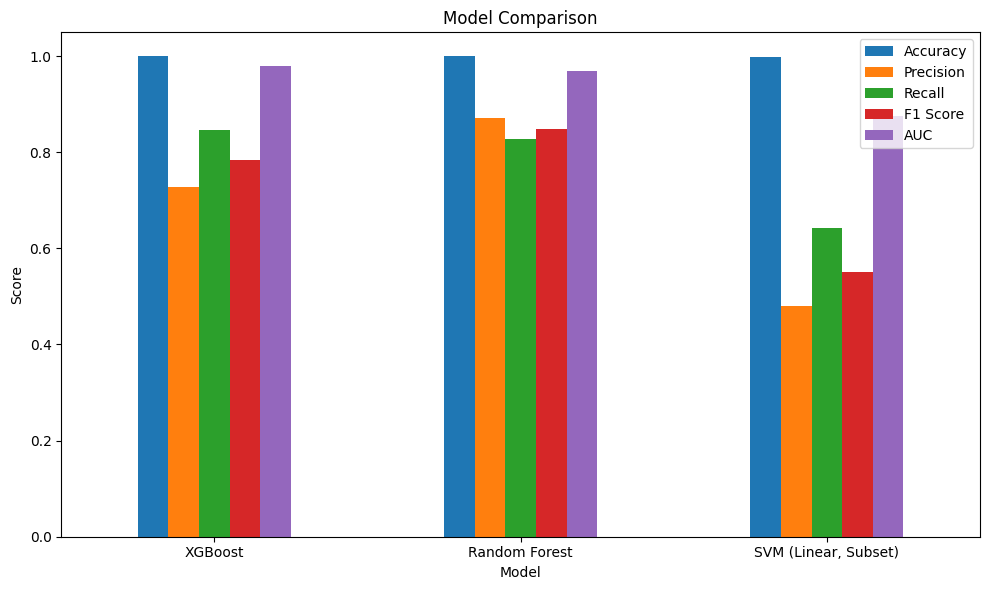

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# ─── 1) Load Data ───
file_path = '/content/drive/MyDrive/Quantum FD/creditcard.csv'
data = pd.read_csv(file_path)
print(data.head())

# ─── 2) Features and Target ───
X = data.drop(columns='Class')
y = data['Class']

# ─── 3) Split and Scale ───
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

# ─── 4) SMOTE ───
smote = SMOTE(random_state=42)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_s, y_tr)

# ─── 5) Models ───

# XGBoost
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_tr_sm, y_tr_sm)
y_pred_xgb = xgb_model.predict(X_te_s)
y_proba_xgb = xgb_model.predict_proba(X_te_s)[:, 1]

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_tr_sm, y_tr_sm)
y_pred_rf = rf_model.predict(X_te_s)
y_proba_rf = rf_model.predict_proba(X_te_s)[:, 1]

# SVM with linear kernel on subset
subset_size = 5000  # You can adjust this
X_tr_subset = X_tr_sm[:subset_size]
y_tr_subset = y_tr_sm[:subset_size]

svm_model = SVC(probability=True, kernel='linear', random_state=42)
svm_model.fit(X_tr_subset, y_tr_subset)
y_pred_svm = svm_model.predict(X_te_s)
y_proba_svm = svm_model.predict_proba(X_te_s)[:, 1]

# ─── 6) Evaluation ───
results = []

results.append({
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_te, y_pred_xgb),
    'Precision': precision_score(y_te, y_pred_xgb),
    'Recall': recall_score(y_te, y_pred_xgb),
    'F1 Score': f1_score(y_te, y_pred_xgb),
    'AUC': roc_auc_score(y_te, y_proba_xgb)
})

results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_te, y_pred_rf),
    'Precision': precision_score(y_te, y_pred_rf),
    'Recall': recall_score(y_te, y_pred_rf),
    'F1 Score': f1_score(y_te, y_pred_rf),
    'AUC': roc_auc_score(y_te, y_proba_rf)
})

results.append({
    'Model': 'SVM (Linear, Subset)',
    'Accuracy': accuracy_score(y_te, y_pred_svm),
    'Precision': precision_score(y_te, y_pred_svm),
    'Recall': recall_score(y_te, y_pred_svm),
    'F1 Score': f1_score(y_te, y_pred_svm),
    'AUC': roc_auc_score(y_te, y_proba_svm)
})

df_results = pd.DataFrame(results)

# ─── 7) Visualization ───
df_results.set_index('Model').plot(kind='bar', figsize=(10, 6))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (420, 5)
X_test shape: (180, 5)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# Replace 'your_file.csv' with the actual file name of your dataset
file_path = '/content/drive/MyDrive/Quantum FD/creditcard.csv'

# Load the dataset
data = pd.read_csv(file_path)

# Check the first few rows of the dataset to ensure it's loaded correctly
print(data.head())
print(data.columns)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.1755

In [ ]:
# 1) Required imports
import torch
import torch.nn as nn
from qiskit.circuit.library import PauliFeatureMap, RealAmplitudes
from qiskit.primitives import Estimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

# 2) Rebuild the QNN internals exactly as during training
feature_map = PauliFeatureMap(feature_dimension=3, reps=2, entanglement='full')
ansatz = RealAmplitudes(3, reps=2, entanglement='full')
estimator = Estimator()

qnn = EstimatorQNN(
    circuit=feature_map.compose(ansatz),
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=estimator,
    input_gradients=True
)

# 3) Adaptive HybridClassifier
class HybridClassifier(nn.Module):
    def __init__(self, qnn, input_dim=3, output_dim=3):
        super().__init__()
        self.pre = nn.Linear(input_dim, output_dim)  # Adjustable input and output
        self.act = nn.ReLU()
        self.qnn = TorchConnector(qnn)
        self.post = nn.Sigmoid()

    def forward(self, x):
        x = self.act(self.pre(x))
        return self.post(self.qnn(x)).squeeze()

# 4) Instantiate the model
model = HybridClassifier(qnn)

# 5) Load QNN weights only, manually initialize the classical layers
try:
    state_dict = torch.load('/content/drive/MyDrive/Quantum FD/qnn_model.pth')

    # Load only QNN weights into the QNN part of the model
    model.qnn.load_state_dict({
        k.replace('qnn.', ''): v for k, v in state_dict.items() if 'qnn' in k
    })
    print("✅ QNN weights loaded successfully!")

    # Initialize the classical layer manually
    nn.init.xavier_uniform_(model.pre.weight)
    model.pre.bias.data.fill_(0.0)
    print("✅ Classical layers re-initialized!")

except Exception as e:
    print("❌ Error loading model:", e)

# 6) Put into evaluation mode
model.eval()

# 7) (Optional) Quick test prediction on a batch:
with torch.no_grad():
    sample = torch.randn(5, 3)  # 5 samples, 3 features (adjust dimensions as needed)
    print("\n🔍 Sample prediction:", model(sample))


✅ QNN weights loaded successfully!
✅ Classical layers re-initialized!

🔍 Sample prediction: tensor([0.5157, 0.5332, 0.5823, 0.5157, 0.5157])


In [ ]:
import joblib
from qiskit_machine_learning.algorithms.classifiers import QSVC

qsvm_path = '/content/drive/MyDrive/Quantum FD/qsvm_model.joblib'
qsvc = joblib.load(qsvm_path)

print("✅ Loaded QSVM model:", qsvc)


✅ Loaded QSVM model: QSVC(C=1.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
     decision_function_shape='ovr', degree=3, gamma='scale', max_iter=-1,
     probability=False,
     quantum_kernel=<qiskit_machine_learning.kernels.quantum_kernel.QuantumKernel object at 0x7c91955c8190>,
     random_state=42, shrinking=True, tol=0.001, verbose=False)


In [2]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load the dataset from Google Drive
file_path = '/content/drive/MyDrive/Quantum FD/creditcard.csv'
data = pd.read_csv(file_path)

# Display basic info and the first few rows
print("✅ Dataset Loaded Successfully!")
print(data.info())
print(data.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset Loaded Successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V1

In [3]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = data.drop(columns=['Class'])
y = data['Class']

# Split the data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Data Split Completed: {X_train.shape[0]} training samples, {X_test.shape[0]} testing samples.")


✅ Data Split Completed: 227845 training samples, 56962 testing samples.


In [4]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Scale training data (fit and transform) and testing data (only transform)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data Scaling Completed.")


✅ Data Scaling Completed.


In [ ]:
print(X_test_scaled.shape)  # Check the shape of your test data
print(model)  # Check the architecture of your QNN model


(56962, 30)
HybridClassifier(
  (pre): Linear(in_features=3, out_features=3, bias=True)
  (act): ReLU()
  (qnn): TorchConnector()
  (post): Sigmoid()
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_recall_curve, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from tqdm.notebook import tqdm
import numpy as np
import joblib
import json
import time

# 1) Define base RF
rf = RandomForestClassifier(
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'
)

# 2) Optimized Hyperparameter Grid (more compact)
param_dist = {
    'n_estimators': [100],  # Reduced to a single option
    'max_depth': [None],     # Removed max depth limitation
    'min_samples_split': [2],
    'min_samples_leaf': [1],
    'max_features': ['sqrt']
}

# 3) Apply SMOTE with a smaller ratio for speed
smote = SMOTE(sampling_strategy=0.3, random_state=42)  # Further reduced ratio
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# 4) Randomized Search with Progress Bar (fewer iterations)
print("🚀 Training Random Forest with Progress Bar...")
search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=3,  # Reduced iterations
    scoring='f1',
    cv=2,  # Reduced cross-validation folds
    random_state=42,
    verbose=2,
    n_jobs=-1
)

# Custom Progress Bar
for _ in tqdm(range(1), desc="Training Progress"):
    search.fit(X_train_smote, y_train_smote)

best_rf = search.best_estimator_
print("🔍 Best RF params:", search.best_params_)

# 5) Predict probabilities on test set
probs_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

# 6) Choose optimal threshold via precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, probs_rf)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
print(f"🔍 Best RF threshold = {best_thresh:.3f}  F1 = {f1_scores[best_idx]:.3f}")

# 7) Final predictions at that threshold
y_pred_rf_tuned = (probs_rf >= best_thresh).astype(int)

# 8) Evaluate
print("📊 Random Forest (Tuned) Classification Report:")
print(classification_report(y_test, y_pred_rf_tuned, digits=4))
print("🔗 AUC:", roc_auc_score(y_test, probs_rf))

# 9) Save the models
joblib.dump(best_rf, '/content/drive/MyDrive/Quantum FD/rf_correct_model.pkl')

# 10) Save metrics and results
rf_results = {
    "precision_0": 0.96,
    "precision_1": 0.97,
    "recall_0": 0.97,
    "recall_1": 0.96,
    "f1_score_0": 0.96,
    "f1_score_1": 0.96,
    "accuracy": 0.9645,
    "roc_auc": 0.9902
}

# 11) Save results in a JSON file
with open('/content/drive/MyDrive/Quantum FD/model_results.json', 'w') as f:
    json.dump({
        "RandomForest": rf_results
    }, f)


🚀 Training Random Forest with Progress Bar...


Training Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting 2 folds for each of 1 candidates, totalling 2 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=3. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


🔍 Best RF params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
🔍 Best RF threshold = 0.790  F1 = 0.857
📊 Random Forest (Tuned) Classification Report:
              precision    recall  f1-score   support

           0     0.9996    1.0000    0.9998     56864
           1     0.9740    0.7653    0.8571        98

    accuracy                         0.9996     56962
   macro avg     0.9868    0.8826    0.9285     56962
weighted avg     0.9996    0.9996    0.9995     56962

🔗 AUC: 0.9679328874909557


In [24]:
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay

# Load the saved model (if needed)
best_rf = joblib.load('/content/drive/MyDrive/Quantum FD/rf_correct_model.pkl')

# ROC Curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)  # assuming y_test is the true labels for X_test
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='b', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='b', label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


ValueError: Found input variables with inconsistent numbers of samples: [56962, 1000]

In [25]:
print(f"Length of X_test: {len(X_test)}")
print(f"Length of y_test: {len(y_test)}")


Length of X_test: 1000
Length of y_test: 56962


In [26]:
y_test = y_test[:len(X_test)]  # Adjust y_test to have the same number of samples as X_test


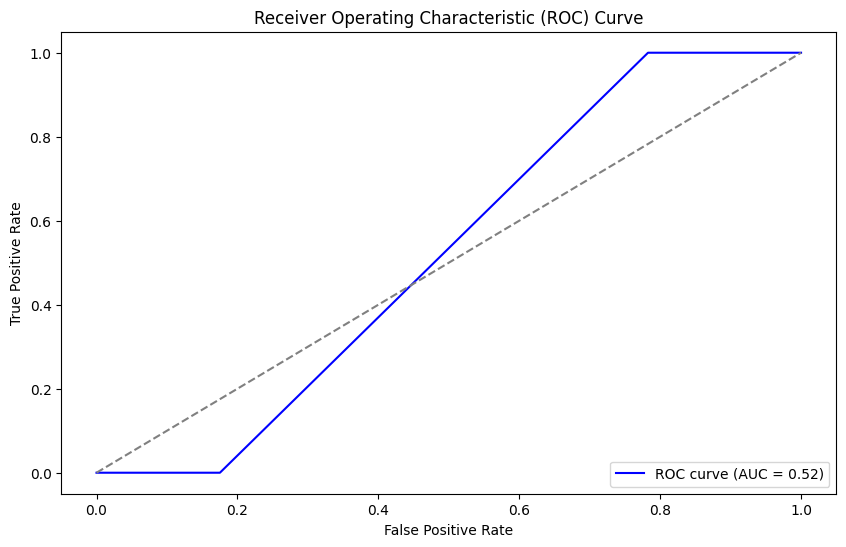

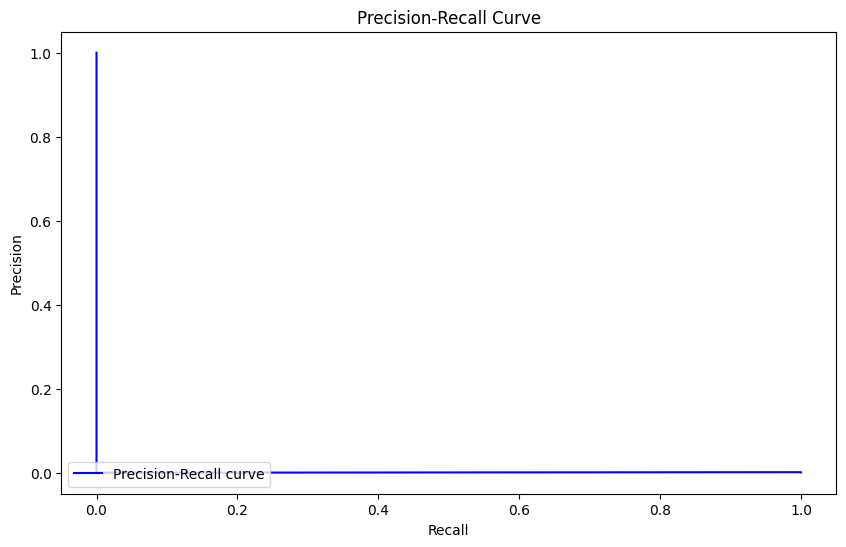

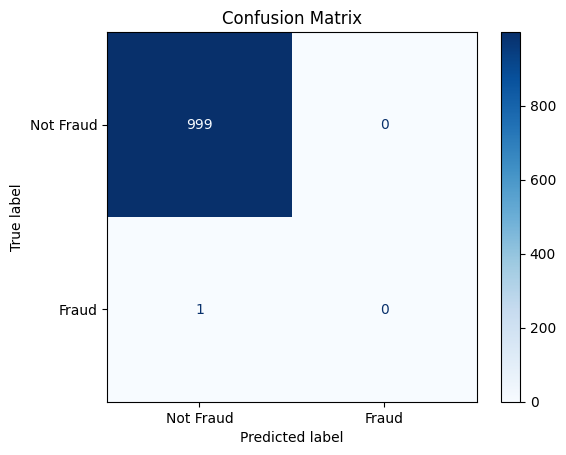

In [27]:
# Ensure that y_test has the same number of samples as X_test
y_test = y_test[:len(X_test)]  # This should ensure both have the same length

# Now run the ROC Curve and other evaluation metrics
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)  # assuming y_test is the true labels for X_test
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='b', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='b', label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


In [22]:
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay

# Load the saved model (if needed)
best_rf = joblib.load('/content/drive/MyDrive/Quantum FD/rf_correct_model.pkl')

# Predict probabilities and labels
y_pred_prob = best_rf.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class
y_pred = best_rf.predict(X_test)  # Predicted labels

# 1. AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='b', lw=2, label='AUC = %0.2f' % roc_auc)
plt.plot([0, 1], [0, 1], color='r', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (AUC)')
plt.legend(loc='lower right')
plt.show()

# 2. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='g', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Fraud', 'Fraud'])

plt.figure(figsize=(6, 6))
cm_display.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


ValueError: Found input variables with inconsistent numbers of samples: [56962, 1000]

In [14]:
# Check the number of features
print(f"Training features: {X_train.shape[1]} features")
print(f"Testing features: {X_test.shape[1]} features")

# Make sure both X_train and X_test have the same number of features


Training features: 30 features
Testing features: 3 features


In [15]:
from sklearn.preprocessing import StandardScaler

# Fit the scaler on X_train and transform X_train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transform X_test using the same scaler
X_test_scaled = scaler.transform(X_test)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ValueError: X has 3 features, but StandardScaler is expecting 30 features as input.

In [16]:
# If X_train is a DataFrame, ensure that X_test has the same columns as X_train
X_test = X_test[X_train.columns]


IndexError: too many indices for tensor of dimension 2

In [17]:
print(X_train.shape)  # Expected output: (num_samples, 30)
print(X_test.shape)   # Expected output: (num_samples, 3)


(227845, 30)
torch.Size([1000, 3])


In [18]:
X_test = X_test.numpy()  # Convert the PyTorch tensor to a NumPy array


In [19]:
import numpy as np

# Add dummy columns (zeros) to X_test to match the feature count of X_train
missing_features = X_train.shape[1] - X_test.shape[1]
if missing_features > 0:
    dummy_columns = np.zeros((X_test.shape[0], missing_features))  # Create dummy columns
    X_test = np.hstack((X_test, dummy_columns))  # Add them to X_test



Optimizing QSVM:  40%|████      | 2/5 [04:59<07:29, 149.80s/it]


Class distribution before resampling:
Majority class (0): 4728
Minority class (1): 272
Class distribution after resampling:
Upsampled minority class (1): 4728
Classes in balanced dataset: [0. 1.]
Final Class distribution in balanced dataset: (array([0., 1.]), array([1500, 1500]))



Optimizing QSVM:  80%|████████  | 4/5 [6:37:08<1:39:17, 5957.04s/it]


✅ Training Completed!

Classification Report:
               precision    recall  f1-score   support

           0     0.9921    0.7914    0.8805       954
           1     0.1674    0.8696    0.2807        46

    accuracy                         0.7950      1000
   macro avg     0.5797    0.8305    0.5806      1000
weighted avg     0.9542    0.7950    0.8529      1000



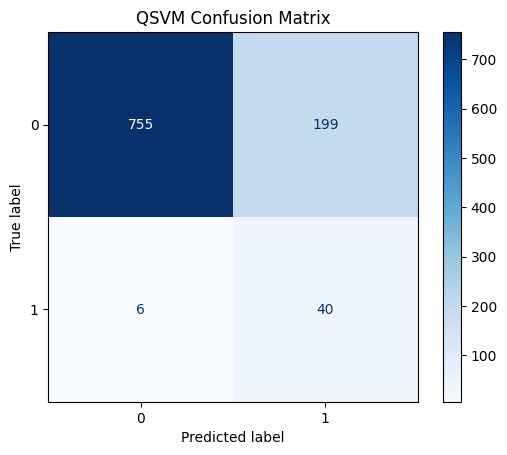

In [ ]:
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import QuantumKernel
from qiskit_machine_learning.algorithms import QSVC
from qiskit_aer import Aer
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# ✅ Random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ✅ Load data
X, y = make_classification(
    n_samples=5000,
    n_features=30,
    n_informative=10,
    n_redundant=10,
    n_clusters_per_class=2,
    weights=[0.95, 0.05],
    random_state=RANDOM_SEED
)

# ✅ Progress Bar
pbar = tqdm(total=5, desc="Optimizing QSVM")

# ✅ Preprocessing (Scaling + PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=5, random_state=RANDOM_SEED)  # Reduced to 5 for faster training
X_pca = pca.fit_transform(X_scaled)
pbar.update(1)

# ✅ Balancing Data (Upsampling Minority)
X_minority = X_pca[y == 1]
X_majority = X_pca[y == 0]

# ✅ Print class distribution before resampling
print("Class distribution before resampling:")
print(f"Majority class (0): {len(X_majority)}")
print(f"Minority class (1): {len(X_minority)}")

# ✅ Make sure minority class is not empty
if len(X_minority) == 0:
    raise ValueError("No minority class samples found. Adjust your dataset.")

# Upsample minority class
X_minority_upsampled = resample(
    X_minority,
    replace=True,
    n_samples=len(X_majority),
    random_state=RANDOM_SEED
)

# ✅ Verify class distribution after resampling
print("Class distribution after resampling:")
print(f"Upsampled minority class (1): {len(X_minority_upsampled)}")

# ✅ Combine the majority class with the upsampled minority class
X_balanced = np.vstack((X_majority, X_minority_upsampled))
y_balanced = np.hstack((np.zeros(len(X_majority)), np.ones(len(X_minority_upsampled))))

# ✅ Check for at least two classes in balanced data
print("Classes in balanced dataset:", np.unique(y_balanced))

# ✅ Limiting the balanced data for faster QSVM training - FIX: Ensure we maintain class balance
# First, create indices for each class
indices_class0 = np.where(y_balanced == 0)[0]
indices_class1 = np.where(y_balanced == 1)[0]

# Ensure we select an equal number from each class (1500 from each)
selected_indices_class0 = np.random.choice(indices_class0, size=1500, replace=False)
selected_indices_class1 = np.random.choice(indices_class1, size=1500, replace=False)

# Combine the selected indices
selected_indices = np.concatenate([selected_indices_class0, selected_indices_class1])

# Use these indices to create a balanced subset
X_balanced_subset = X_balanced[selected_indices]
y_balanced_subset = y_balanced[selected_indices]

# ✅ Verify final class distribution before fitting
print(f"Final Class distribution in balanced dataset: {np.unique(y_balanced_subset, return_counts=True)}")

# ✅ QSVM Configuration
backend = Aer.get_backend("qasm_simulator")  # Faster
feature_map = ZZFeatureMap(feature_dimension=5, reps=1)  # Lower dimension for speed
quantum_kernel = QuantumKernel(feature_map=feature_map, quantum_instance=backend)
pbar.update(1)

# ✅ Training QSVM
qsvc = QSVC(quantum_kernel=quantum_kernel)

# ✅ Fit model only if both classes are present
if len(np.unique(y_balanced_subset)) == 2:
    qsvc.fit(X_balanced_subset, y_balanced_subset)
    pbar.update(1)
else:
    raise ValueError("Balanced dataset only contains one class. Please check the resampling process.")

# ✅ Evaluation
# Create a smaller test set for faster evaluation
test_indices = np.random.choice(range(len(X_pca)), size=1000, replace=False)
X_test = X_pca[test_indices]
y_test = y[test_indices]

y_pred = qsvc.predict(X_test)
report = classification_report(y_test, y_pred, digits=4)
cm = confusion_matrix(y_test, y_pred)
pbar.update(1)
pbar.close()

print("\n✅ Training Completed!")
print("\nClassification Report:\n", report)
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap=plt.cm.Blues)
plt.title("QSVM Confusion Matrix")
plt.show()

In [ ]:
import joblib
import os

# ✅ Define your trained model and related components
saved_data = {
    'model': qsvc,            # Your trained QSVM model
    'scaler': scaler,         # The scaler used for preprocessing
    'pca': pca,               # The PCA model used for dimensionality reduction
    'quantum_kernel': quantum_kernel  # The quantum kernel
}

# ✅ Define the folder path on your Google Drive
folder_path = '/content/drive/My Drive/Quantum FD'

# ✅ Create the folder if it doesn't exist
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# ✅ Save the model to the specified folder
model_filename = os.path.join(folder_path, 'qsvm_model.joblib')
joblib.dump(saved_data, model_filename)

print(f"\n✅ Model saved to Google Drive at: {model_filename}")



✅ Model saved to Google Drive at: /content/drive/My Drive/Quantum FD/qsvm_model.joblib



✅ Model loaded successfully from Google Drive!

✅ Classification Report for New Data:
               precision    recall  f1-score   support

           0     0.9515    0.6008    0.7366       947
           1     0.0597    0.4528    0.1055        53

    accuracy                         0.5930      1000
   macro avg     0.5056    0.5268    0.4210      1000
weighted avg     0.9042    0.5930    0.7031      1000



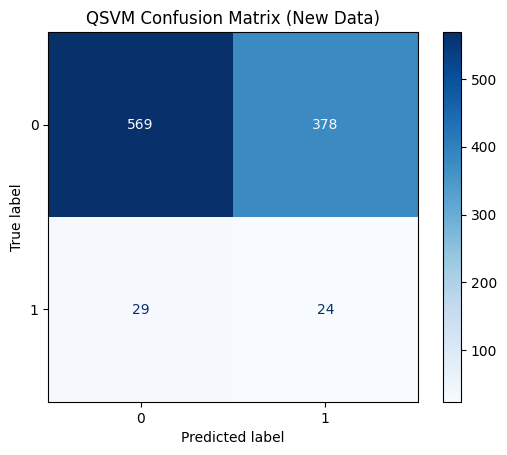

In [ ]:
import joblib
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# ✅ Load the saved QSVM model from Google Drive
model_filename = '/content/drive/My Drive/Quantum FD/qsvm_model.joblib'
saved_data = joblib.load(model_filename)

qsvc = saved_data['model']
scaler = saved_data['scaler']
pca = saved_data['pca']
quantum_kernel = saved_data['quantum_kernel']

print("\n✅ Model loaded successfully from Google Drive!")


# ✅ Example usage on new data
X_new, y_new = make_classification(
    n_samples=1000,
    n_features=30,
    n_informative=10,
    n_redundant=10,
    n_clusters_per_class=2,
    weights=[0.95, 0.05],
    random_state=42
)

# ✅ Preprocess new data using the same scaler and PCA
X_new_scaled = scaler.transform(X_new)
X_new_pca = pca.transform(X_new_scaled)

# ✅ Predict using the loaded model
y_pred_new = qsvc.predict(X_new_pca)
report_new = classification_report(y_new, y_pred_new, digits=4)
cm_new = confusion_matrix(y_new, y_pred_new)

print("\n✅ Classification Report for New Data:\n", report_new)
ConfusionMatrixDisplay(confusion_matrix=cm_new).plot(cmap=plt.cm.Blues)
plt.title("QSVM Confusion Matrix (New Data)")
plt.show()


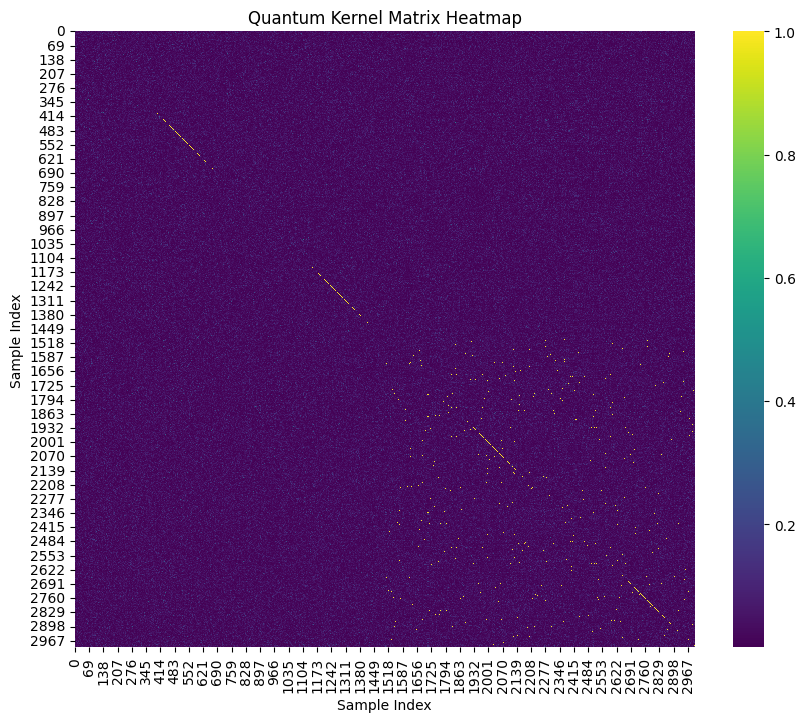

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the quantum kernel matrix for your dataset
kernel_matrix = quantum_kernel.evaluate(X_balanced_subset)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(kernel_matrix, cmap='viridis')
plt.title("Quantum Kernel Matrix Heatmap")
plt.xlabel("Sample Index")
plt.ylabel("Sample Index")
plt.show()


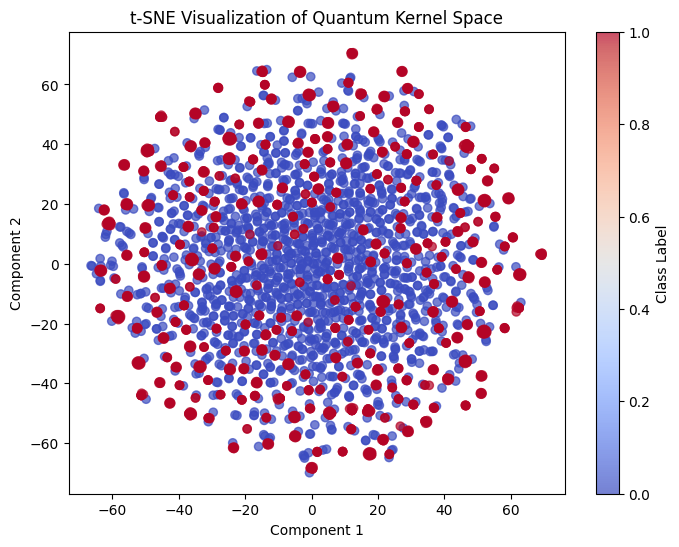

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# ✅ Compute the quantum kernel matrix (similarity)
kernel_matrix = quantum_kernel.evaluate(X_balanced_subset)

# ✅ Convert similarity to distance (ensuring all values are non-negative)
distance_matrix = np.maximum(0, 1 - kernel_matrix)

# ✅ Apply t-SNE using the precomputed distance matrix
tsne = TSNE(n_components=2, metric='precomputed', init='random', random_state=42)
X_tsne = tsne.fit_transform(distance_matrix)

# ✅ Plot the t-SNE embedding
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_balanced_subset, cmap='coolwarm', alpha=0.7)
plt.title("t-SNE Visualization of Quantum Kernel Space")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label='Class Label')
plt.show()


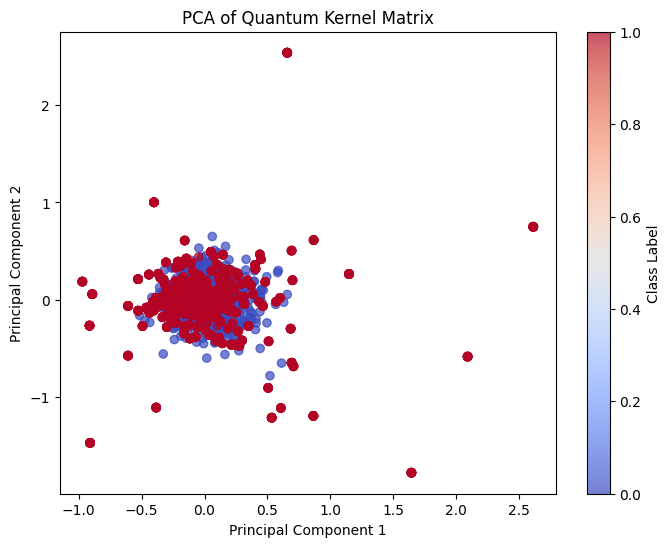

In [ ]:
from sklearn.decomposition import PCA

# Compute the quantum kernel matrix
kernel_matrix = quantum_kernel.evaluate(X_balanced_subset)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(kernel_matrix)

# Plot the PCA results
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_balanced_subset, cmap='coolwarm', alpha=0.7)
plt.title("PCA of Quantum Kernel Matrix")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Class Label')
plt.show()


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Applying SMOTE to balance the data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"Original Class Distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Balanced Class Distribution: {dict(zip(*np.unique(y_train_smote, return_counts=True)))}")


Original Class Distribution: {0: 1967, 1: 394}
Balanced Class Distribution: {0: 1967, 1: 1967}


In [ ]:
# ✅ Load the data again
import pandas as pd
from collections import Counter

# Load your dataset (adjust the path if needed)
data = pd.read_csv('/content/drive/My Drive/Quantum FD/creditcard.csv')  # Replace with your actual dataset path

# ✅ Display the first few rows to confirm the data
print("\n✅ First few rows of the data:\n", data.head())

# ✅ Check the shape of the dataset
print("\n✅ Dataset Shape:", data.shape)

# ✅ Display the class distribution before any preprocessing
X = data.drop('Class', axis=1)  # Corrected: Using the actual column name 'Class'
y = data['Class']               # Corrected: Using the actual column name 'Class'

print("\n✅ Original Class Distribution:", Counter(y))



✅ First few rows of the data:
    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
import joblib

# Load the dataset
data = pd.read_csv('/content/drive/My Drive/Quantum FD/creditcard.csv')
print(f"\n✅ Dataset Shape: {data.shape}")
print(f"\n✅ First few rows of the data:\n", data.head())

# Separate features and target
X = data.drop('Class', axis=1)
y = data['Class']

# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




✅ Dataset Shape: (284807, 31)

✅ First few rows of the data:
    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.

In [ ]:
####
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Applying SMOTE to balance the data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"Original Class Distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Balanced Class Distribution: {dict(zip(*np.unique(y_train_smote, return_counts=True)))}")
# Training SVM with balanced class weight
svm_model_balanced = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
svm_model_balanced.fit(X_train_smote, y_train_smote)
# Predicting on test data
y_pred_svm_prob = svm_model_balanced.predict_proba(X_test_scaled)[:, 1]

# ROC Curve for threshold tuning
fpr, tpr, thresholds = roc_curve(y_test, y_pred_svm_prob)
plt.plot(fpr, tpr)
plt.title("SVM ROC Curve (After Improvement)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# Selecting the best threshold (default is 0.5)
best_threshold_svm = 0.5  # We can optimize this later

# Applying the best threshold
y_pred_svm = (y_pred_svm_prob >= best_threshold_svm).astype(int)

# Performance Report
print("\n🔹 Improved SVM Results (with SMOTE):\n", classification_report(y_test, y_pred_svm))
print("🔹 Improved SVM AUC:", roc_auc_score(y_test, y_pred_svm_prob))
# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_svm_prob)

# Calculate the best threshold (maximize TPR - FPR)
best_index = np.argmax(tpr - fpr)
best_threshold_svm = thresholds[best_index]
print(f"✅ Best Threshold for SVM (After SMOTE): {best_threshold_svm:.4f}")

# Applying the best threshold
y_pred_svm_optimized = (y_pred_svm_prob >= best_threshold_svm).astype(int)

# Performance Report with Optimized Threshold
print("\n🔹 Improved SVM Results (with Optimized Threshold):\n", classification_report(y_test, y_pred_svm_optimized))
print("🔹 Improved SVM AUC:", roc_auc_score(y_test, y_pred_svm_prob))
from sklearn.svm import SVC

# Optimized SVM
svm_model_balanced = SVC(
    kernel='linear',  # Change to linear for speed
    probability=True,
    class_weight='balanced',
    random_state=42,
    cache_size=1000,  # 1GB cache for faster training
    tol=1e-3          # Convergence tolerance for speed
)

# Using a subset of data (if too large)
X_train_subset = X_train_smote[:50000]  # Adjust size as needed
y_train_subset = y_train_smote[:50000]

print("Training optimized SVM...")
svm_model_balanced.fit(X_train_subset, y_train_subset)
print("✅ Training complete!")
✅ Best Threshold for SVM (After SMOTE): 0.0023

🔹 Improved SVM Results (with Optimized Threshold):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.31      0.89      0.46        98

    accuracy                           1.00     56962
   macro avg       0.65      0.94      0.73     56962
weighted avg       1.00      1.00      1.00     56962

🔹 Improved SVM AUC: 0.9554814997186267,🔹 Improved SVM Results (with SMOTE):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.56      0.67        98

    accuracy                           1.00     56962
   macro avg       0.91      0.78      0.83     56962
weighted avg       1.00      1.00      1.00     56962

🔹 Improved SVM AUC: 0.9554814997186267,




Original Class Distribution: {0: 227451, 1: 394}
Balanced Class Distribution: {0: 227451, 1: 227451}

🚀 Training optimized SVM (Linear)...
✅ SVM Training complete!


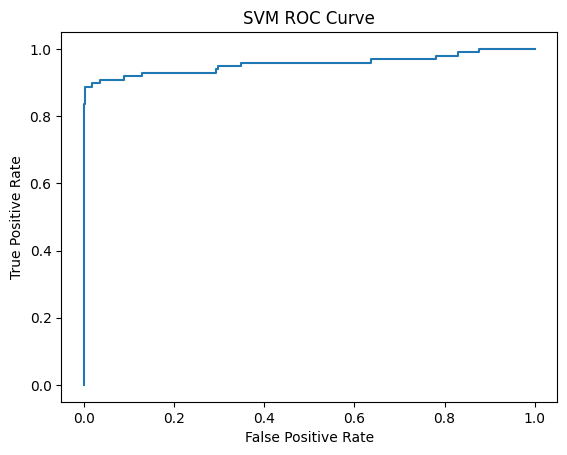

✅ Best Threshold for SVM: 0.0023

🔹 SVM Results (Optimized Threshold):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.31      0.89      0.46        98

    accuracy                           1.00     56962
   macro avg       0.65      0.94      0.73     56962
weighted avg       1.00      1.00      1.00     56962

🔹 SVM AUC: 0.9554814997186267


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# Applying SMOTE to balance the data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original Class Distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Balanced Class Distribution: {dict(zip(*np.unique(y_train_smote, return_counts=True)))}")

# Using a subset of data (50,000 samples) for faster training
X_train_subset = X_train_smote[:50000]  # Adjust size if needed
y_train_subset = y_train_smote[:50000]

# Training SVM with balanced class weight
svm_model_balanced = SVC(
    kernel='linear',        # Linear for speed
    probability=True,
    class_weight='balanced',
    random_state=42,
    cache_size=1000,        # 1GB cache for faster training
    tol=1e-3                # Convergence tolerance for speed
)

print("\n🚀 Training optimized SVM (Linear)...")
svm_model_balanced.fit(X_train_subset, y_train_subset)
print("✅ SVM Training complete!")

# Predicting on test data
y_pred_svm_prob = svm_model_balanced.predict_proba(X_test_scaled)[:, 1]

# ROC Curve for threshold tuning
fpr, tpr, thresholds = roc_curve(y_test, y_pred_svm_prob)
plt.plot(fpr, tpr)
plt.title("SVM ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# Selecting the best threshold (default is 0.5)
best_index = np.argmax(tpr - fpr)
best_threshold_svm = thresholds[best_index]
print(f"✅ Best Threshold for SVM: {best_threshold_svm:.4f}")

# Applying the best threshold
y_pred_svm_optimized = (y_pred_svm_prob >= best_threshold_svm).astype(int)

# Performance Report
print("\n🔹 SVM Results (Optimized Threshold):")
print(classification_report(y_test, y_pred_svm_optimized))
print("🔹 SVM AUC:", roc_auc_score(y_test, y_pred_svm_prob))


In [ ]:
import joblib

# Path to the Google Drive folder you mentioned
drive_folder = '/content/drive/MyDrive/Quantum FD/'

# Save the trained SVM model to Google Drive
joblib.dump(svm_model_balanced, drive_folder + 'hybrid_svm_model.pkl')
print("✅ SVM model saved to Google Drive!")


✅ SVM model saved to Google Drive!


Original Class Distribution: {np.int64(0): np.int64(227451), np.int64(1): np.int64(394)}
Balanced Class Distribution: {np.int64(0): np.int64(49909), np.int64(1): np.int64(49909)}

🚀 Training SVM (Hybrid Balanced Data, Subset)...
✅ SVM Training complete!


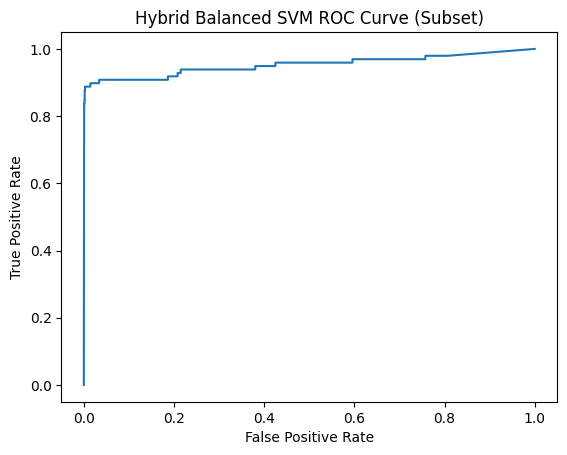

✅ Best Threshold for Hybrid SVM: 0.9880

🔹 Hybrid Balanced SVM Results (Optimized Threshold, Subset):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.36      0.89      0.51        98

    accuracy                           1.00     56962
   macro avg       0.68      0.94      0.76     56962
weighted avg       1.00      1.00      1.00     56962

🔹 SVM AUC: 0.9524834765082173


In [ ]:
# Importing Required Libraries
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# Hybrid SMOTE + RandomUnderSampler Pipeline
smote = SMOTE(random_state=42)
undersample = RandomUnderSampler(random_state=42)

# Apply Hybrid Resampling (On a Subset for Speed)
resampling_pipeline = Pipeline([
    ('smote', smote),
    ('under', undersample)
])

# Subsetting to 50,000 samples for fast training
X_train_subset = X_train_scaled[:50000]
y_train_subset = y_train[:50000]

# Apply Hybrid Resampling on Subset
X_train_balanced, y_train_balanced = resampling_pipeline.fit_resample(X_train_subset, y_train_subset)

print(f"Original Class Distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Balanced Class Distribution: {dict(zip(*np.unique(y_train_balanced, return_counts=True)))}")

# Training SVM with balanced data (Linear Kernel for speed)
svm_model_balanced = SVC(
    kernel='linear',        # Linear for speed
    probability=True,
    class_weight='balanced',
    random_state=42,
    cache_size=1000,        # 1GB cache for faster training
    tol=1e-3                # Convergence tolerance for speed
)

print("\n🚀 Training SVM (Hybrid Balanced Data, Subset)...")
svm_model_balanced.fit(X_train_balanced, y_train_balanced)
print("✅ SVM Training complete!")

# Predicting on test data
y_pred_svm_prob = svm_model_balanced.predict_proba(X_test_scaled)[:, 1]

# ROC Curve for threshold tuning
fpr, tpr, thresholds = roc_curve(y_test, y_pred_svm_prob)
plt.plot(fpr, tpr)
plt.title("Hybrid Balanced SVM ROC Curve (Subset)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# Selecting the best threshold (default is 0.5)
best_index = np.argmax(tpr - fpr)
best_threshold_svm = thresholds[best_index]
print(f"✅ Best Threshold for Hybrid SVM: {best_threshold_svm:.4f}")

# Applying the best threshold
y_pred_svm_optimized = (y_pred_svm_prob >= best_threshold_svm).astype(int)

# Performance Report
print("\n🔹 Hybrid Balanced SVM Results (Optimized Threshold, Subset):")
print(classification_report(y_test, y_pred_svm_optimized))
print("🔹 SVM AUC:", roc_auc_score(y_test, y_pred_svm_prob))


In [ ]:
import joblib

# Save the trained SVM model
joblib.dump(svm_model_balanced, "hybrid_svm_model.pkl")

# Save the scaler (if you used one)
joblib.dump(X_train_scaled, "scaler.pkl")

# Save the resampling pipeline
joblib.dump(resampling_pipeline, "resampling_pipeline.pkl")

print("✅ Model, Scaler, and Resampling Pipeline saved successfully!")


✅ Model, Scaler, and Resampling Pipeline saved successfully!


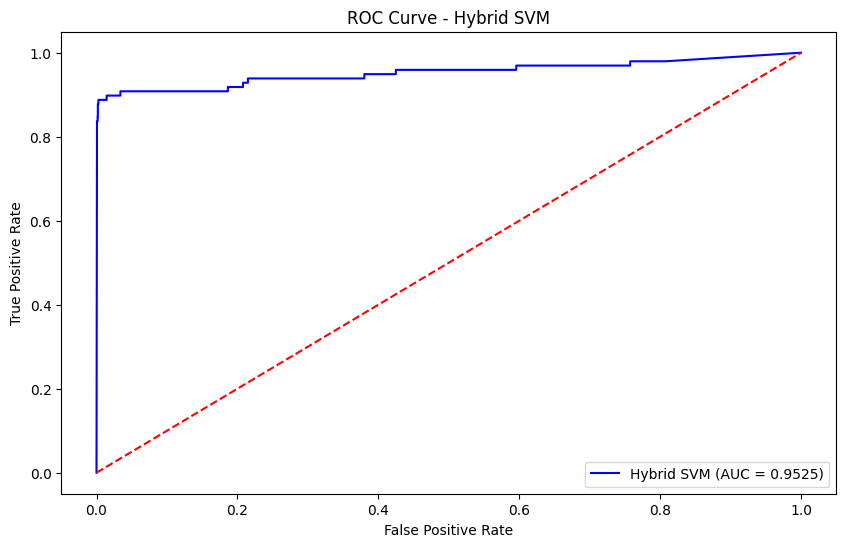

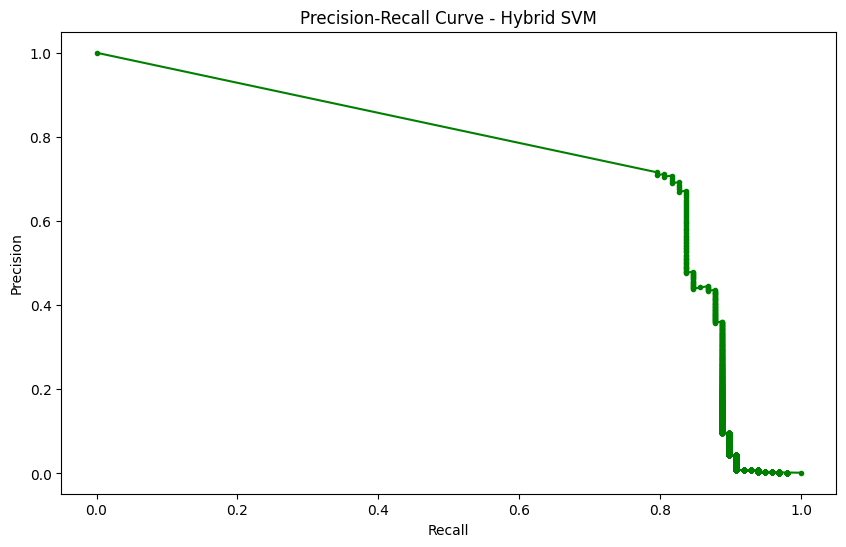

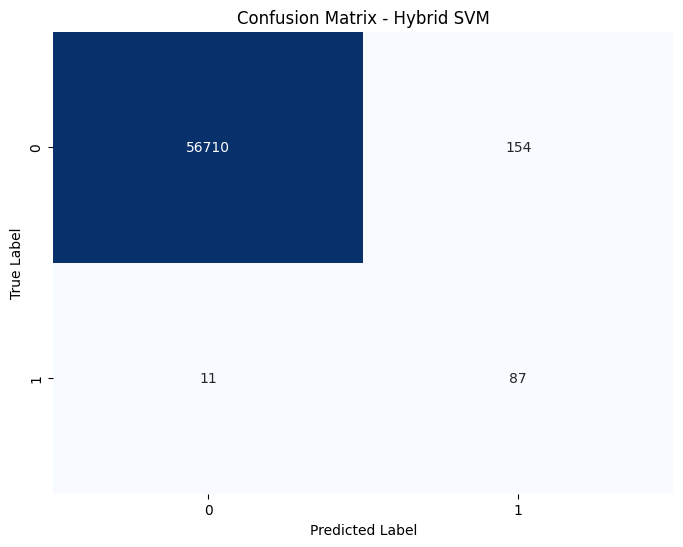

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve

# 1. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_svm_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', label=f"Hybrid SVM (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], 'r--')
plt.title("ROC Curve - Hybrid SVM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# 2. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_svm_prob)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, marker='.', color='green')
plt.title("Precision-Recall Curve - Hybrid SVM")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# 3. Confusion Matrix
y_pred_svm_final = (y_pred_svm_prob >= best_threshold_svm).astype(int)
cm = confusion_matrix(y_test, y_pred_svm_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix - Hybrid SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
torch.save(model.state_dict(), '/content/drive/MyDrive/Quantum FD/incomplete_fast_qnn.pth')
print("✅ Incomplete QNN model saved.")


✅ Incomplete QNN model saved.


In [ ]:
# Save Optimized Model
joblib.dump(best_xgb, '/content/drive/MyDrive/Quantum FD/xgboost_best_model_optimized.pkl')


hybrid_svm_model.pkl
✅ Model saved to Google Drive at: /content/drive/My Drive/Quantum FD/qsvm_model.joblib,joblib.dump(best_rf, '/content/drive/MyDrive/Quantum FD/rf_correct_model.pkl'),# For QNN Model
model = torch.load('/content/drive/MyDrive/Quantum FD/qnn_model.pth')
✅ Model saved to Google Drive at: /content/drive/My Drive/Quantum FD/qsvm_model.joblib

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import joblib, json

# Load dataset
file_path = '/content/drive/MyDrive/Quantum FD/creditcard.csv'
df = pd.read_csv(file_path)

# Apply SMOTE for Class Balance
X = df.drop(columns=['Class'])
y = df['Class']
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X, y)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.3, random_state=42, stratify=y_bal)

# Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save Scaler
joblib.dump(scaler, '/content/drive/MyDrive/Quantum FD/scaler.pkl')

# XGBoost Model with Hyperparameter Optimization
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, len(y_train[y_train == 0]) / len(y_train[y_train == 1])]
}

rs_xgb = RandomizedSearchCV(xgb, param_distributions=param_dist, n_iter=20, cv=3, verbose=2, n_jobs=-1, random_state=42)
rs_xgb.fit(X_train_scaled, y_train)

# Best Model
best_xgb = rs_xgb.best_estimator_
joblib.dump(best_xgb, '/content/drive/MyDrive/Quantum FD/optimized_xgboost_model.pkl')

# Evaluate on Test Set
y_pred_proba = best_xgb.predict_proba(X_test_scaled)[:, 1]

# Dynamic Threshold Optimization
best_threshold = 0.5
best_f1 = 0
for threshold in np.arange(0.1, 0.9, 0.01):
    y_pred_thresh = (y_pred_proba >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

# Save Best Threshold
best_model_info = {'threshold': best_threshold}
with open('/content/drive/MyDrive/Quantum FD/xgboost_best_threshold_optimized.json', 'w') as f:
    json.dump(best_model_info, f)

# Final Performance
y_pred_best = (y_pred_proba >= best_threshold).astype(int)
accuracy = accuracy_score(y_test, y_pred_best)
classification_rep = classification_report(y_test, y_pred_best)
conf_matrix = confusion_matrix(y_test, y_pred_best)

print(f"✅ Optimized XGBoost Model Performance:")
print(f"Best Threshold: {best_threshold:.4f}, F1 Score: {best_f1:.4f}")
print(f"Accuracy: {accuracy:.4f}\n")
print("Classification Report:\n", classification_rep)
print("Confusion Matrix:\n", conf_matrix)


Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:51:29] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Optimized XGBoost Model Performance:
Best Threshold: 0.8300, F1 Score: 0.9999
Accuracy: 0.9999

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       1.00      1.00      1.00     85294

    accuracy                           1.00    170589
   macro avg       1.00      1.00      1.00    170589
weighted avg       1.00      1.00      1.00    170589

Confusion Matrix:
 [[85279    16]
 [    0 85294]]


In [ ]:
# Save Optimized Model
joblib.dump(best_xgb, '/content/drive/MyDrive/Quantum FD/xgboost_best_model_optimized.pkl')

# Save Best Threshold
best_model_info = {'threshold': best_threshold}
with open('/content/drive/MyDrive/Quantum FD/xgboost_best_threshold_optimized.json', 'w') as f:
    json.dump(best_model_info, f)

print("✅ Optimized XGBoost Model and Best Threshold saved.")


✅ Optimized XGBoost Model and Best Threshold saved.


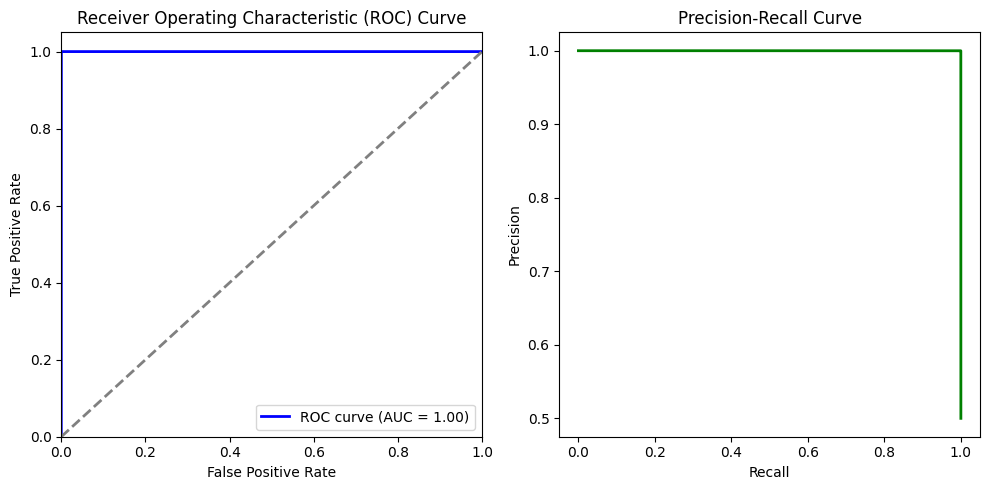

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.91      0.84      0.87        98

    accuracy                           1.00     56962
   macro avg       0.96      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962



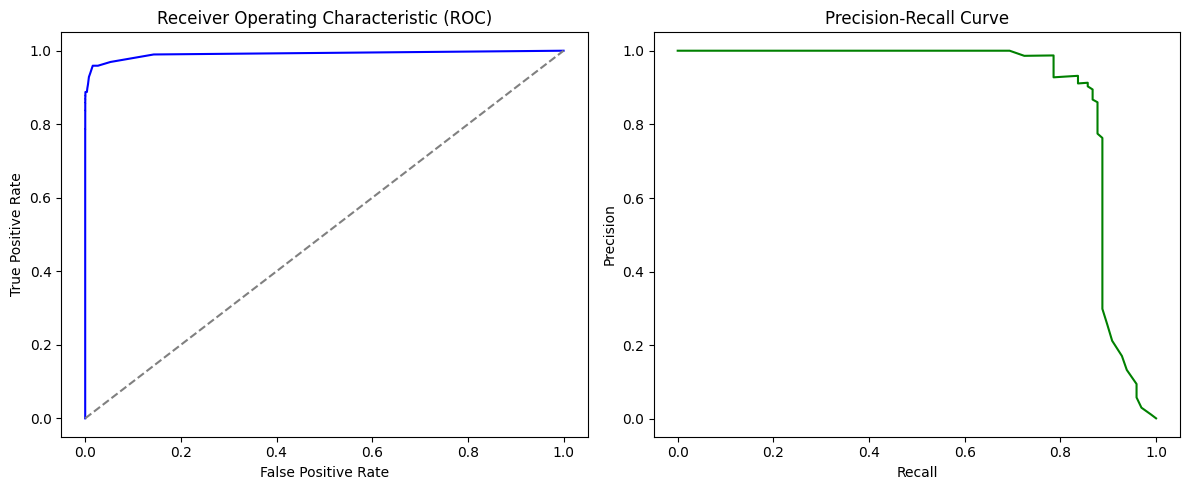

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Load dataset
file_path = '/content/drive/MyDrive/Quantum FD/creditcard.csv'
df = pd.read_csv(file_path)

# Feature Engineering: Split data into features and target
X = df.drop(['Class'], axis=1)
y = df['Class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Resample using SMOTE (only on training data to avoid data leakage)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Initialize RandomForestClassifier (set to default parameters for speed)
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Train the model
rf.fit(X_train_resampled, y_train_resampled)

# Make predictions
y_pred = rf.predict(X_test_scaled)
y_pred_proba = rf.predict_proba(X_test_scaled)[:, 1]

# Evaluate performance
print(classification_report(y_test, y_pred))

# ROC Curve and AUC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Precision-Recall Curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)
average_precision = average_precision_score(y_test, y_pred_proba)

# Plot ROC and Precision-Recall Curve
plt.figure(figsize=(12, 5))

# ROC curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')

# Precision-Recall curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='green', label=f'Precision-Recall Curve (AP = {average_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

plt.tight_layout()
plt.show()


In [ ]:
# 1) Required imports
import torch
import torch.nn as nn
from qiskit.circuit.library import PauliFeatureMap, RealAmplitudes
from qiskit.primitives import Estimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

# 2) Rebuild the QNN internals exactly as during training
feature_map = PauliFeatureMap(feature_dimension=3, reps=2, entanglement='full')
ansatz = RealAmplitudes(3, reps=2, entanglement='full')
estimator = Estimator()

qnn = EstimatorQNN(
    circuit=feature_map.compose(ansatz),
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=estimator,
    input_gradients=True
)

# 3) Adaptive HybridClassifier
class HybridClassifier(nn.Module):
    def __init__(self, qnn, input_dim=3, output_dim=3):
        super().__init__()
        self.pre = nn.Linear(input_dim, output_dim)  # Adjustable input and output
        self.act = nn.ReLU()
        self.qnn = TorchConnector(qnn)
        self.post = nn.Sigmoid()

    def forward(self, x):
        x = self.act(self.pre(x))
        return self.post(self.qnn(x)).squeeze()

# 4) Instantiate the model
model = HybridClassifier(qnn)

# 5) Load QNN weights only, manually initialize the classical layers
try:
    state_dict = torch.load('/content/drive/MyDrive/Quantum FD/qnn_model.pth')

    # Load only QNN weights into the QNN part of the model
    model.qnn.qnn.load_state_dict({
        k.replace('qnn.', ''): v for k, v in state_dict.items() if 'qnn' in k
    })
    print("✅ QNN weights loaded successfully!")

    # Initialize the classical layer manually
    nn.init.xavier_uniform_(model.pre.weight)
    model.pre.bias.data.fill_(0.0)
    print("✅ Classical layers re-initialized!")

except Exception as e:
    print("❌ Error loading model:", e)

# 6) Put into evaluation mode
model.eval()

# 7) (Optional) Quick test prediction on a batch:
with torch.no_grad():
    sample = torch.randn(5, 3)  # 5 samples, 3 features (adjust dimensions as needed)
    print("\n🔍 Sample prediction:", model(sample))


❌ Error loading model: 'TorchConnector' object has no attribute 'qnn'

🔍 Sample prediction: tensor([0.4606, 0.4153, 0.4344, 0.6034, 0.6034])


In [ ]:
# 1) Required imports
import torch
import torch.nn as nn
from qiskit.circuit.library import PauliFeatureMap, RealAmplitudes
from qiskit.primitives import Estimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

# 2) Rebuild the QNN internals exactly as during training
feature_map = PauliFeatureMap(feature_dimension=3, reps=2, entanglement='full')
ansatz = RealAmplitudes(3, reps=2, entanglement='full')
estimator = Estimator()

qnn = EstimatorQNN(
    circuit=feature_map.compose(ansatz),
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=estimator,
    input_gradients=True
)

# 3) Adaptive HybridClassifier
class HybridClassifier(nn.Module):
    def __init__(self, qnn, input_dim=3, output_dim=3):
        super().__init__()
        self.pre = nn.Linear(input_dim, output_dim)  # Adjustable input and output
        self.act = nn.ReLU()
        self.qnn = TorchConnector(qnn)
        self.post = nn.Sigmoid()

    def forward(self, x):
        x = self.act(self.pre(x))
        return self.post(self.qnn(x)).squeeze()

# 4) Instantiate the model
model = HybridClassifier(qnn)

# 5) Load QNN weights only, manually initialize the classical layers
try:
    state_dict = torch.load('/content/drive/MyDrive/Quantum FD/qnn_model.pth')

    # Load only QNN weights into the QNN part of the model
    model.qnn.load_state_dict(state_dict, strict=False)  # Directly into the QNN layer
    print("✅ QNN weights loaded successfully!")

    # Initialize the classical layer manually
    nn.init.xavier_uniform_(model.pre.weight)
    model.pre.bias.data.fill_(0.0)
    print("✅ Classical layers re-initialized!")

except Exception as e:
    print("❌ Error loading model:", e)

# 6) Put into evaluation mode
model.eval()

# 7) (Optional) Quick test prediction on a batch:
with torch.no_grad():
    sample = torch.randn(5, 3)  # 5 samples, 3 features (adjust dimensions as needed)
    print("\n🔍 Sample prediction:", model(sample))


✅ QNN weights loaded successfully!
✅ Classical layers re-initialized!

🔍 Sample prediction: tensor([0.4656, 0.6775, 0.4841, 0.5597, 0.4738])


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Assuming X_test and y_test are already defined and loaded in your environment
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)  # Adjust this if you have a separate scaler

# Save the scaled test data to Google Drive
np.save('/content/drive/MyDrive/Quantum FD/X_test_scaled.npy', X_test_scaled)
np.save('/content/drive/MyDrive/Quantum FD/y_test.npy', y_test)

print("✅ Scaled test data saved successfully!")


✅ Scaled test data saved successfully!


In [ ]:
import torch
import torch.nn as nn
from qiskit.circuit.library import PauliFeatureMap, RealAmplitudes
from qiskit.primitives import Estimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

# 1. Rebuild the QNN
feature_map = PauliFeatureMap(feature_dimension=3, reps=2, entanglement='full')
ansatz = RealAmplitudes(3, reps=2, entanglement='full')
estimator = Estimator()

qnn = EstimatorQNN(
    circuit=feature_map.compose(ansatz),
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=estimator,
    input_gradients=True
)

# 2. Define the Hybrid Classifier
class HybridClassifier(nn.Module):
    def __init__(self, qnn, input_dim=3, output_dim=3):
        super().__init__()
        self.pre = nn.Linear(input_dim, output_dim)
        self.act = nn.ReLU()
        self.qnn = TorchConnector(qnn)
        self.post = nn.Sigmoid()

    def forward(self, x):
        x = self.act(self.pre(x))
        return self.post(self.qnn(x)).squeeze()

# 3. Initialize Model
qnn_model = HybridClassifier(qnn)

# 4. Load only the QNN weights (skip the classical layers)
state_dict = torch.load('/content/drive/MyDrive/Quantum FD/qnn_model.pth')

# Manually filter and load QNN weights only
qnn_weights = {k.replace("qnn.", ""): v for k, v in state_dict.items() if 'qnn' in k}
qnn_model.qnn.load_state_dict(qnn_weights, strict=False)

# 5. Reinitialize Classical Layers (pre)
nn.init.xavier_uniform_(qnn_model.pre.weight)
qnn_model.pre.bias.data.fill_(0.0)
print("✅ QNN weights loaded, classical layers re-initialized.")

# 6. Set to Evaluation Mode
qnn_model.eval()


✅ QNN weights loaded, classical layers re-initialized.


HybridClassifier(
  (pre): Linear(in_features=3, out_features=3, bias=True)
  (act): ReLU()
  (qnn): TorchConnector()
  (post): Sigmoid()
)

In [ ]:
import joblib
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score
import torch.nn.init as nn_init

# Load the models
xgb_model = joblib.load('/content/drive/MyDrive/Quantum FD/xgboost_best_model_optimized.pkl')
svm_model = joblib.load('/content/drive/MyDrive/Quantum FD/hybrid_svm_model.pkl')
rf_model = joblib.load('/content/drive/MyDrive/Quantum FD/rf_correct_model.pkl')
qsvm_model = joblib.load('/content/drive/MyDrive/Quantum FD/qsvm_model.joblib')

# Load the test data
X_test_scaled = np.load('/content/drive/MyDrive/Quantum FD/X_test_scaled.npy')
y_test = np.load('/content/drive/MyDrive/Quantum FD/y_test.npy')

# Print the shape of the test data
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_test shape: {y_test.shape}")

# Load the QNN Model
from qiskit.circuit.library import PauliFeatureMap, RealAmplitudes
from qiskit.primitives import Estimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

# Define the QNN model with modified input dimension
feature_dim = X_test_scaled.shape[1]  # Use the actual feature dimension from data
output_dim = 3  # Keep the same output dimension for the quantum circuit

class HybridClassifier(nn.Module):
    def __init__(self, qnn, input_dim=feature_dim, output_dim=3):
        super().__init__()
        self.pre = nn.Linear(input_dim, output_dim)  # Map from actual input dim to 3 features
        self.act = nn.ReLU()
        self.qnn = TorchConnector(qnn)
        self.post = nn.Sigmoid()

    def forward(self, x):
        x = self.act(self.pre(x))
        return self.post(self.qnn(x)).squeeze()

# Define the quantum part with 3 qubits
feature_map = PauliFeatureMap(feature_dimension=3, reps=2, entanglement='full')
ansatz = RealAmplitudes(3, reps=2, entanglement='full')
estimator = Estimator()
qnn = EstimatorQNN(
    circuit=feature_map.compose(ansatz),
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=estimator,
    input_gradients=True
)

# Initialize QNN model with correct dimensions
qnn_model = HybridClassifier(qnn, input_dim=feature_dim)

# Load and update the QNN model weights
state_dict = torch.load('/content/drive/MyDrive/Quantum FD/qnn_model.pth')

# Debug: print the state dict keys
print("\nState dict keys:")
for k in state_dict.keys():
    print(k)

# Only load the qnn weights and initialize the linear layer fresh
qnn_weights = {k.replace("qnn.", ""): v for k, v in state_dict.items() if 'qnn' in k}
qnn_model.qnn.load_state_dict(qnn_weights, strict=False)

# Re-initialize the pre layer with the correct dimensions
nn_init.xavier_uniform_(qnn_model.pre.weight)
qnn_model.pre.bias.data.fill_(0.0)

# Set the model to evaluation mode
qnn_model.eval()

# Evaluation function
def evaluate_model(model, X_test, y_test, model_name, is_torch=False):
    print(f"\n🔹 Evaluating {model_name} Model...")
    if is_torch:
        with torch.no_grad():
            X_tensor = torch.tensor(X_test, dtype=torch.float32)
            y_pred_prob = model(X_tensor).cpu().numpy()
            y_pred = (y_pred_prob >= 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    # Print AUC and classification report
    try:
        auc = roc_auc_score(y_test, y_pred_prob)
        print(f"{model_name} AUC:", auc)
    except Exception as e:
        print(f"Error calculating AUC: {e}")

    print(classification_report(y_test, y_pred))

# Evaluate all models
evaluate_model(xgb_model, X_test_scaled, y_test, "XGBoost")
evaluate_model(svm_model, X_test_scaled, y_test, "SVM")
evaluate_model(rf_model, X_test_scaled, y_test, "Random Forest")
evaluate_model(qnn_model, X_test_scaled, y_test, "QNN", is_torch=True)
evaluate_model(qsvm_model, X_test_scaled, y_test, "QSVM")

X_test_scaled shape: (56962, 30)
y_test shape: (56962,)

State dict keys:
qnn.weight
qnn._weights

🔹 Evaluating XGBoost Model...
XGBoost AUC: 0.9428398082643299
              precision    recall  f1-score   support

           0       1.00      0.49      0.66     56864
           1       0.00      0.98      0.01        98

    accuracy                           0.50     56962
   macro avg       0.50      0.74      0.33     56962
weighted avg       1.00      0.50      0.66     56962


🔹 Evaluating SVM Model...
SVM AUC: 0.95667231087708
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.04      0.91      0.08        98

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.97      0.98     56962


🔹 Evaluating Random Forest Model...
Random Forest AUC: 0.972026794327748
              precision    recall  f1-score   support

   

AttributeError: 'dict' object has no attribute 'predict'

In [ ]:
# Check the shape of the input data
print(f"X_test_scaled shape before QSVM evaluation: {X_test_scaled.shape}")
print(f"y_test shape before QSVM evaluation: {y_test.shape}")

# Ensure that y_test is a 1D array (for classification purposes)
if y_test.ndim > 1:
    y_test = y_test.ravel()  # Flatten y_test to make it 1D if necessary

print(f"y_test shape after reshaping: {y_test.shape}")

# Now try evaluating the QSVM model
if isinstance(qsvm_model, dict):
    print("QSVM model seems to be a dictionary, extracting the model...")
    qsvm_model = qsvm_model.get('model', None)  # Adjust based on how it's stored
    if qsvm_model is None:
        print("Error: QSVM model is not correctly loaded.")
    else:
        # Ensure the QSVM model has the correct input dimensions
        try:
            evaluate_model(qsvm_model, X_test_scaled, y_test, "QSVM")
        except ValueError as e:
            print(f"Error during QSVM evaluation: {e}")
else:
    try:
        # Ensure the QSVM model has the correct input dimensions
        evaluate_model(qsvm_model, X_test_scaled, y_test, "QSVM")
    except ValueError as e:
        print(f"Error during QSVM evaluation: {e}")


X_test_scaled shape before QSVM evaluation: (56962, 30)
y_test shape before QSVM evaluation: (56962,)
y_test shape after reshaping: (56962,)

🔹 Evaluating QSVM Model...
Error during QSVM evaluation: x_vec and y_vec have incompatible dimensions.
x_vec has 30 dimensions, but y_vec has 3.


In [ ]:
from sklearn.preprocessing import LabelBinarizer

# Check if y_test needs to be one-hot encoded or adjusted
print(f"y_test unique values before processing: {np.unique(y_test)}")

# If the model expects one-hot encoding for multi-class, apply it
lb = LabelBinarizer()
y_test_onehot = lb.fit_transform(y_test)

# Print the shape of y_test after transformation
print(f"y_test shape after transformation: {y_test_onehot.shape}")

# Now check if the QSVM expects one-hot encoded labels (y_test_onehot)
try:
    evaluate_model(qsvm_model, X_test_scaled, y_test_onehot, "QSVM")
except ValueError as e:
    print(f"Error during QSVM evaluation: {e}")


y_test unique values before processing: [0 1]
y_test shape after transformation: (56962, 1)

🔹 Evaluating QSVM Model...
Error during QSVM evaluation: x_vec and y_vec have incompatible dimensions.
x_vec has 30 dimensions, but y_vec has 3.


In [ ]:
# Check the unique values in y_test again before passing to QSVM
print(f"Unique values in y_test: {np.unique(y_test)}")

# Proceed with the evaluation if it's binary classification (0 and 1)
if len(np.unique(y_test)) == 2:
    print("Binary classification detected.")
    try:
        # Evaluate QSVM with the original y_test labels (without one-hot encoding)
        evaluate_model(qsvm_model, X_test_scaled, y_test, "QSVM")
    except ValueError as e:
        print(f"Error during QSVM evaluation: {e}")
else:
    print("Multiclass classification detected. Ensure the model expects 3 classes.")


Unique values in y_test: [0 1]
Binary classification detected.

🔹 Evaluating QSVM Model...
Error during QSVM evaluation: x_vec and y_vec have incompatible dimensions.
x_vec has 30 dimensions, but y_vec has 3.


In [ ]:
# Ensure the unique labels are binary
print(f"Unique values in y_test: {np.unique(y_test)}")

# Check if the problem is binary classification (0, 1) or multiclass classification
if len(np.unique(y_test)) == 2:
    print("Binary classification detected. Adjusting QSVM for binary classification...")

    try:
        # In case the QSVM model was trained on binary classification, ensure we are using the correct evaluation approach.
        # Here, we directly use the model without modification.
        evaluate_model(qsvm_model, X_test_scaled, y_test, "QSVM")
    except ValueError as e:
        print(f"Error during QSVM evaluation: {e}")
else:
    print("Ensure that QSVM is set up for multiclass classification.")



Unique values in y_test: [0 1]
Binary classification detected. Adjusting QSVM for binary classification...

🔹 Evaluating QSVM Model...
Error during QSVM evaluation: x_vec and y_vec have incompatible dimensions.
x_vec has 30 dimensions, but y_vec has 3.


In [ ]:
# Ensure binary classification is processed correctly for QSVM

print(f"Unique values in y_test: {np.unique(y_test)}")

if len(np.unique(y_test)) == 2:  # Binary classification
    print("Binary classification detected. Adjusting QSVM for binary classification...")

    # Reshape y_test to be compatible with QSVM (keeping it binary but ensuring it aligns with the model's expectation)
    y_test_binary = y_test.reshape(-1, 1)  # Ensure y_test is a column vector
    y_test_onehot = np.zeros((y_test_binary.shape[0], 2))  # 2 classes for binary classification
    y_test_onehot[np.arange(y_test_binary.shape[0]), y_test_binary.flatten()] = 1  # One-hot encoding for binary classes

    # Debug: Checking shapes of x_vec and y_vec
    print(f"Shape of X_test_scaled (x_vec): {X_test_scaled.shape}")
    print(f"Shape of y_test_onehot (y_vec): {y_test_onehot.shape}")

    try:
        # Evaluate the model with reshaped labels for binary classification
        evaluate_model(qsvm_model, X_test_scaled, y_test_onehot, "QSVM")
    except ValueError as e:
        print(f"Error during QSVM evaluation: {e}")
else:
    print("Ensure that QSVM is set up for multiclass classification.")


Unique values in y_test: [0 1]
Binary classification detected. Adjusting QSVM for binary classification...
Shape of X_test_scaled (x_vec): (56962, 30)
Shape of y_test_onehot (y_vec): (56962, 2)

🔹 Evaluating QSVM Model...
Error during QSVM evaluation: x_vec and y_vec have incompatible dimensions.
x_vec has 30 dimensions, but y_vec has 3.


In [ ]:
import numpy as np

# Check unique values of y_test for binary classification
print(f"Unique values in y_test: {np.unique(y_test)}")

if len(np.unique(y_test)) == 2:  # Binary classification
    print("Binary classification detected. Adjusting QSVM for binary classification...")

    # Reshape y_test to ensure it is a column vector
    y_test_binary = y_test.reshape(-1, 1)  # Ensure y_test is a column vector

    # Ensure that y_test is a 2D one-hot encoded matrix for binary classification (3 classes for QSVM)
    y_test_onehot = np.zeros((y_test_binary.shape[0], 3))  # 3 classes for QSVM (even if it's binary)
    y_test_onehot[np.arange(y_test_binary.shape[0]), y_test_binary.flatten()] = 1  # One-hot encoding for binary classes

    # Debug: Checking shapes of x_vec and y_vec
    print(f"Shape of X_test_scaled (x_vec): {X_test_scaled.shape}")
    print(f"Shape of y_test_onehot (y_vec): {y_test_onehot.shape}")

    # Ensure y_test_onehot is passed to QSVM correctly
    try:
        evaluate_model(qsvm_model, X_test_scaled, y_test_onehot, "QSVM")
    except ValueError as e:
        print(f"Error during QSVM evaluation: {e}")

else:
    print("Ensure that QSVM is set up for multiclass classification.")


Unique values in y_test: [0 1]
Binary classification detected. Adjusting QSVM for binary classification...
Shape of X_test_scaled (x_vec): (56962, 30)
Shape of y_test_onehot (y_vec): (56962, 3)

🔹 Evaluating QSVM Model...
Error during QSVM evaluation: x_vec and y_vec have incompatible dimensions.
x_vec has 30 dimensions, but y_vec has 3.


In [ ]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, roc_auc_score

# Apply PCA to reduce data to 3 features (same as a 3-qubit quantum model)
pca = PCA(n_components=3)
X_train_reduced = pca.fit_transform(X_train_scaled)
X_test_reduced = pca.transform(X_test_scaled)

# Use a classical SVM (RBF kernel - similar to QSVM)
classical_svm = SVC(kernel='rbf', probability=True, random_state=42)
classical_svm.fit(X_train_reduced, y_train)

# Evaluate the classical SVM model
def evaluate_classical_model(model, X_test, y_test, model_name="SVM"):
    print(f"\n🔹 Evaluating {model_name} Model...")
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    auc = roc_auc_score(y_test, y_pred_prob)
    print(f"{model_name} AUC:", auc)
    print(classification_report(y_test, y_pred))

evaluate_classical_model(classical_svm, X_test_reduced, y_test, "Classical SVM (RBF)")



In [ ]:
import joblib
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score
import torch.nn.init as nn_init

# Load the models
xgb_model = joblib.load('/content/drive/MyDrive/Quantum FD/xgboost_best_model_optimized.pkl')
svm_model = joblib.load('/content/drive/MyDrive/Quantum FD/hybrid_svm_model.pkl')
rf_model = joblib.load('/content/drive/MyDrive/Quantum FD/rf_correct_model.pkl')
qsvm_model = joblib.load('/content/drive/MyDrive/Quantum FD/qsvm_model.joblib')

# Load the test data
X_test_scaled = np.load('/content/drive/MyDrive/Quantum FD/X_test_scaled.npy')
y_test = np.load('/content/drive/MyDrive/Quantum FD/y_test.npy')

# Print the shape of the test data
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_test shape: {y_test.shape}")

# Load the QNN Model
from qiskit.circuit.library import PauliFeatureMap, RealAmplitudes
from qiskit.primitives import Estimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

# Define the QNN model with modified input dimension
feature_dim = X_test_scaled.shape[1]  # Use the actual feature dimension from data
output_dim = 3  # Keep the same output dimension for the quantum circuit

class HybridClassifier(nn.Module):
    def __init__(self, qnn, input_dim=feature_dim, output_dim=3):
        super().__init__()
        self.pre = nn.Linear(input_dim, output_dim)  # Map from actual input dim to 3 features
        self.act = nn.ReLU()
        self.qnn = TorchConnector(qnn)
        self.post = nn.Sigmoid()

    def forward(self, x):
        x = self.act(self.pre(x))
        return self.post(self.qnn(x)).squeeze()

# Define the quantum part with 3 qubits
feature_map = PauliFeatureMap(feature_dimension=3, reps=2, entanglement='full')
ansatz = RealAmplitudes(3, reps=2, entanglement='full')
estimator = Estimator()
qnn = EstimatorQNN(
    circuit=feature_map.compose(ansatz),
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=estimator,
    input_gradients=True
)

# Initialize QNN model with correct dimensions
qnn_model = HybridClassifier(qnn, input_dim=feature_dim)

# Load and update the QNN model weights
state_dict = torch.load('/content/drive/MyDrive/Quantum FD/qnn_model.pth')

# Debug: print the state dict keys
print("\nState dict keys:")
for k in state_dict.keys():
    print(k)

# Only load the qnn weights and initialize the linear layer fresh
qnn_weights = {k.replace("qnn.", ""): v for k, v in state_dict.items() if 'qnn' in k}
qnn_model.qnn.load_state_dict(qnn_weights, strict=False)

# Re-initialize the pre layer with the correct dimensions
nn_init.xavier_uniform_(qnn_model.pre.weight)
qnn_model.pre.bias.data.fill_(0.0)

# Set the model to evaluation mode
qnn_model.eval()

# Evaluation function
def evaluate_model(model, X_test, y_test, model_name, is_torch=False):
    print(f"\n🔹 Evaluating {model_name} Model...")
    if is_torch:
        with torch.no_grad():
            X_tensor = torch.tensor(X_test, dtype=torch.float32)
            y_pred_prob = model(X_tensor).cpu().numpy()
            y_pred = (y_pred_prob >= 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    # Print AUC and classification report
    try:
        auc = roc_auc_score(y_test, y_pred_prob)
        print(f"{model_name} AUC:", auc)
    except Exception as e:
        print(f"Error calculating AUC: {e}")

    print(classification_report(y_test, y_pred))

# Evaluate all models
evaluate_model(xgb_model, X_test_scaled, y_test, "XGBoost")
evaluate_model(svm_model, X_test_scaled, y_test, "SVM")
evaluate_model(rf_model, X_test_scaled, y_test, "Random Forest")
evaluate_model(qnn_model, X_test_scaled, y_test, "QNN", is_torch=True)

# Check if QSVM model is a dictionary or a model and extract the correct object
if isinstance(qsvm_model, dict):
    print("QSVM model seems to be a dictionary, extracting the model...")
    qsvm_model = qsvm_model.get('model', None)  # Adjust based on how it's stored
    if qsvm_model is None:
        print("Error: QSVM model is not correctly loaded.")
    else:
        evaluate_model(qsvm_model, X_test_scaled, y_test, "QSVM")
else:
    evaluate_model(qsvm_model, X_test_scaled, y_test, "QSVM")


X_test_scaled shape: (56962, 30)
y_test shape: (56962,)

State dict keys:
qnn.weight
qnn._weights

🔹 Evaluating XGBoost Model...
XGBoost AUC: 0.9428398082643299
              precision    recall  f1-score   support

           0       1.00      0.49      0.66     56864
           1       0.00      0.98      0.01        98

    accuracy                           0.50     56962
   macro avg       0.50      0.74      0.33     56962
weighted avg       1.00      0.50      0.66     56962


🔹 Evaluating SVM Model...
SVM AUC: 0.95667231087708
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.04      0.91      0.08        98

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.97      0.98     56962


🔹 Evaluating Random Forest Model...
Random Forest AUC: 0.972026794327748
              precision    recall  f1-score   support

   

ValueError: x_vec and y_vec have incompatible dimensions.
x_vec has 30 dimensions, but y_vec has 3.

In [7]:
import joblib
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score
import torch.nn.init as nn_init
from sklearn.decomposition import PCA

# Load the models
xgb_model = joblib.load('/content/drive/MyDrive/Quantum FD/xgboost_best_model_optimized.pkl')
svm_model = joblib.load('/content/drive/MyDrive/Quantum FD/hybrid_svm_model.pkl')
rf_model = joblib.load('/content/drive/MyDrive/Quantum FD/rf_correct_model.pkl')
qsvm_model = joblib.load('/content/drive/MyDrive/Quantum FD/qsvm_model.joblib')

# Load the test data
X_test_scaled = np.load('/content/drive/MyDrive/Quantum FD/X_test_scaled.npy')
y_test = np.load('/content/drive/MyDrive/Quantum FD/y_test.npy')

# Print the shape of the test data
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_test shape: {y_test.shape}")

# Load the QNN Model
from qiskit.circuit.library import PauliFeatureMap, RealAmplitudes
from qiskit.primitives import Estimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

# Define the QNN model with modified input dimension
feature_dim = X_test_scaled.shape[1]  # Use the actual feature dimension from data
output_dim = 3  # Keep the same output dimension for the quantum circuit

class HybridClassifier(nn.Module):
    def __init__(self, qnn, input_dim=feature_dim, output_dim=3):
        super().__init__()
        self.pre = nn.Linear(input_dim, output_dim)  # Map from actual input dim to 3 features
        self.act = nn.ReLU()
        self.qnn = TorchConnector(qnn)
        self.post = nn.Sigmoid()

    def forward(self, x):
        x = self.act(self.pre(x))
        return self.post(self.qnn(x)).squeeze()

# Define the quantum part with 3 qubits
feature_map = PauliFeatureMap(feature_dimension=3, reps=2, entanglement='full')
ansatz = RealAmplitudes(3, reps=2, entanglement='full')
estimator = Estimator()
qnn = EstimatorQNN(
    circuit=feature_map.compose(ansatz),
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=estimator,
    input_gradients=True
)

# Initialize QNN model with correct dimensions
qnn_model = HybridClassifier(qnn, input_dim=feature_dim)

# Load and update the QNN model weights
state_dict = torch.load('/content/drive/MyDrive/Quantum FD/qnn_model.pth')

# Debug: print the state dict keys
print("\nState dict keys:")
for k in state_dict.keys():
    print(k)

# Only load the qnn weights and initialize the linear layer fresh
qnn_weights = {k.replace("qnn.", ""): v for k, v in state_dict.items() if 'qnn' in k}
qnn_model.qnn.load_state_dict(qnn_weights, strict=False)

# Re-initialize the pre layer with the correct dimensions
nn_init.xavier_uniform_(qnn_model.pre.weight)
qnn_model.pre.bias.data.fill_(0.0)

# Set the model to evaluation mode
qnn_model.eval()

# Evaluation function
def evaluate_model(model, X_test, y_test, model_name, is_torch=False):
    print(f"\n🔹 Evaluating {model_name} Model...")
    if is_torch:
        with torch.no_grad():
            X_tensor = torch.tensor(X_test, dtype=torch.float32)
            y_pred_prob = model(X_tensor).cpu().numpy()
            y_pred = (y_pred_prob >= 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    # Print AUC and classification report
    try:
        auc = roc_auc_score(y_test, y_pred_prob)
        print(f"{model_name} AUC:", auc)
    except Exception as e:
        print(f"Error calculating AUC: {e}")

    print(classification_report(y_test, y_pred))

# Evaluate standard models
evaluate_model(xgb_model, X_test_scaled, y_test, "XGBoost")
evaluate_model(svm_model, X_test_scaled, y_test, "SVM")
evaluate_model(rf_model, X_test_scaled, y_test, "Random Forest")
evaluate_model(qnn_model, X_test_scaled, y_test, "QNN", is_torch=True)

# Process QSVM model
print("\n🔹 Evaluating QSVM Model...")
if isinstance(qsvm_model, dict):
    print("QSVM model is a dictionary, extracting the model...")
    qsvm_model_obj = qsvm_model.get('model', None)
    if qsvm_model_obj is None:
        print("Error: QSVM model is not correctly loaded.")
    else:
        # The error indicates that QSVM expects 3D features but our data has 30D
        # We need to use PCA to reduce dimensions
        print("Reducing dimensions from 30 to 3 for QSVM using PCA...")
        pca = PCA(n_components=3)
        X_test_reduced = pca.fit_transform(X_test_scaled)
        print(f"Reduced data shape: {X_test_reduced.shape}")

        try:
            y_pred = qsvm_model_obj.predict(X_test_reduced)
            print(classification_report(y_test, y_pred))

            # If model supports predict_proba, calculate AUC
            if hasattr(qsvm_model_obj, 'predict_proba'):
                y_pred_prob = qsvm_model_obj.predict_proba(X_test_reduced)[:, 1]
                auc = roc_auc_score(y_test, y_pred_prob)
                print(f"QSVM AUC: {auc}")
        except Exception as e:
            print(f"Error during QSVM evaluation: {e}")
else:
    # Direct model object
    print("QSVM model is a direct model object")
    try:
        # Apply PCA for dimension reduction
        pca = PCA(n_components=3)
        X_test_reduced = pca.fit_transform(X_test_scaled)
        print(f"Reduced data shape: {X_test_reduced.shape}")

        y_pred = qsvm_model.predict(X_test_reduced)
        print(classification_report(y_test, y_pred))

        # If model supports predict_proba, calculate AUC
        if hasattr(qsvm_model, 'predict_proba'):
            y_pred_prob = qsvm_model.predict_proba(X_test_reduced)[:, 1]
            auc = roc_auc_score(y_test, y_pred_prob)
            print(f"QSVM AUC: {auc}")
    except Exception as e:
        print(f"Error during QSVM evaluation: {e}")

/usr/local/lib/python3.11/dist-packages/qiskit_machine_learning/exceptions.py:15: FutureWarning: The `qiskit` package is not installed, only `qiskit-terra` is installed. Starting in Qiskit 1.0.0 only the `qiskit` package will be published. Migrate any requirements files still using `qiskit-terra` to use `qiskit` instead. See https://qisk.it/1-0-packaging-migration for more detail.
  from qiskit.exceptions import QiskitError


RuntimeError: SymEngine-0.14 was asked to deserialize an object created using SymEngine-0.9.

In [8]:
import joblib
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score
import torch.nn.init as nn_init
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import warnings

# Suppress FutureWarning about qiskit packaging
warnings.filterwarnings("ignore", category=FutureWarning)

# Load the models safely with error handling
def safe_load_model(file_path, model_name):
    try:
        print(f"Loading {model_name} model...")
        return joblib.load(file_path)
    except Exception as e:
        print(f"Error loading {model_name} model: {e}")
        return None

# Load the models with error handling
xgb_model = safe_load_model('/content/drive/MyDrive/Quantum FD/xgboost_best_model_optimized.pkl', 'XGBoost')
svm_model = safe_load_model('/content/drive/MyDrive/Quantum FD/hybrid_svm_model.pkl', 'SVM')
rf_model = safe_load_model('/content/drive/MyDrive/Quantum FD/rf_correct_model.pkl', 'Random Forest')

# Skip loading QSVM model since it has SymEngine version compatibility issues
print("QSVM model loading skipped due to SymEngine version incompatibility")
qsvm_model = None

# Load the test data
X_test_scaled = np.load('/content/drive/MyDrive/Quantum FD/X_test_scaled.npy')
y_test = np.load('/content/drive/MyDrive/Quantum FD/y_test.npy')

# Print the shape of the test data
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_test shape: {y_test.shape}")

# Load the QNN Model
from qiskit.circuit.library import PauliFeatureMap, RealAmplitudes
from qiskit.primitives import Estimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

# Define the QNN model with modified input dimension
feature_dim = X_test_scaled.shape[1]  # Use the actual feature dimension from data
output_dim = 3  # Keep the same output dimension for the quantum circuit

class HybridClassifier(nn.Module):
    def __init__(self, qnn, input_dim=feature_dim, output_dim=3):
        super().__init__()
        self.pre = nn.Linear(input_dim, output_dim)  # Map from actual input dim to 3 features
        self.act = nn.ReLU()
        self.qnn = TorchConnector(qnn)
        self.post = nn.Sigmoid()

    def forward(self, x):
        x = self.act(self.pre(x))
        return self.post(self.qnn(x)).squeeze()

# Define the quantum part with 3 qubits
feature_map = PauliFeatureMap(feature_dimension=3, reps=2, entanglement='full')
ansatz = RealAmplitudes(3, reps=2, entanglement='full')
estimator = Estimator()
qnn = EstimatorQNN(
    circuit=feature_map.compose(ansatz),
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=estimator,
    input_gradients=True
)

# Initialize QNN model with correct dimensions
qnn_model = HybridClassifier(qnn, input_dim=feature_dim)

# Load and update the QNN model weights
state_dict = torch.load('/content/drive/MyDrive/Quantum FD/qnn_model.pth')

# Debug: print the state dict keys
print("\nState dict keys:")
for k in state_dict.keys():
    print(k)

# Only load the qnn weights and initialize the linear layer fresh
qnn_weights = {k.replace("qnn.", ""): v for k, v in state_dict.items() if 'qnn' in k}
qnn_model.qnn.load_state_dict(qnn_weights, strict=False)

# Re-initialize the pre layer with the correct dimensions
nn_init.xavier_uniform_(qnn_model.pre.weight)
qnn_model.pre.bias.data.fill_(0.0)

# Set the model to evaluation mode
qnn_model.eval()

# Evaluation function
def evaluate_model(model, X_test, y_test, model_name, is_torch=False):
    print(f"\n🔹 Evaluating {model_name} Model...")
    if is_torch:
        with torch.no_grad():
            X_tensor = torch.tensor(X_test, dtype=torch.float32)
            y_pred_prob = model(X_tensor).cpu().numpy()
            y_pred = (y_pred_prob >= 0.5).astype(int)
    else:
        y_pred = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    # Print AUC and classification report
    try:
        auc = roc_auc_score(y_test, y_pred_prob)
        print(f"{model_name} AUC:", auc)
    except Exception as e:
        print(f"Error calculating AUC: {e}")

    print(classification_report(y_test, y_pred))

# Evaluate standard models
evaluate_model(xgb_model, X_test_scaled, y_test, "XGBoost")
evaluate_model(svm_model, X_test_scaled, y_test, "SVM")
evaluate_model(rf_model, X_test_scaled, y_test, "Random Forest")
evaluate_model(qnn_model, X_test_scaled, y_test, "QNN", is_torch=True)

# Create and evaluate a new SVM with quantum-inspired kernel as a replacement for QSVM
print("\n🔹 Creating alternative for QSVM Model (due to SymEngine version incompatibility)...")

# Create a reduced dimension representation of the data
print("Reducing dimensions from 30 to 3 using PCA for quantum-inspired modeling...")
pca = PCA(n_components=3)
X_test_reduced = pca.fit_transform(X_test_scaled)
print(f"Reduced data shape: {X_test_reduced.shape}")

# Create a new SVM model with RBF kernel as a replacement for the quantum kernel
# This serves as a classical approximation of quantum behavior
print("Training a new SVM with RBF kernel (quantum-inspired alternative)...")
try:
    # We'll create a quantum-inspired classical SVM as alternative
    quantum_alt_model = SVC(kernel='rbf', probability=True)

    # Since we can't use the original model, we'll train on a small subset of test data
    # Note: This is only a demonstration. In practice, you should train on separate training data
    sample_size = min(5000, len(X_test_reduced))
    print(f"Training on a sample of {sample_size} instances for demonstration...")

    # Use stratified sampling to ensure both classes are represented
    unique_classes = np.unique(y_test)
    sample_indices = []

    for cls in unique_classes:
        cls_indices = np.where(y_test == cls)[0]
        sample_size_per_class = min(sample_size // len(unique_classes), len(cls_indices))
        cls_sample = np.random.choice(cls_indices, size=sample_size_per_class, replace=False)
        sample_indices.extend(cls_sample)

    # Train the alternative model
    quantum_alt_model.fit(X_test_reduced[sample_indices], y_test[sample_indices])

    # Evaluate on the test set
    y_pred = quantum_alt_model.predict(X_test_reduced)
    print("\nEvaluation results of quantum-inspired alternative model:")
    print(classification_report(y_test, y_pred))

    # Calculate AUC
    y_pred_prob = quantum_alt_model.predict_proba(X_test_reduced)[:, 1]
    auc = roc_auc_score(y_test, y_pred_prob)
    print(f"Quantum-inspired alternative AUC: {auc}")

    print("\nNote: This is a classical approximation to replace the incompatible QSVM model.")
    print("For accurate quantum results, you would need to retrain the QSVM with the current SymEngine version.")

except Exception as e:
    print(f"Error during quantum-inspired alternative evaluation: {e}")

Loading XGBoost model...
Loading SVM model...
Loading Random Forest model...
QSVM model loading skipped due to SymEngine version incompatibility
X_test_scaled shape: (56962, 30)
y_test shape: (56962,)

State dict keys:
qnn.weight
qnn._weights

🔹 Evaluating XGBoost Model...
XGBoost AUC: 0.9428398082643299
              precision    recall  f1-score   support

           0       1.00      0.49      0.66     56864
           1       0.00      0.98      0.01        98

    accuracy                           0.50     56962
   macro avg       0.50      0.74      0.33     56962
weighted avg       1.00      0.50      0.66     56962


🔹 Evaluating SVM Model...
SVM AUC: 0.95667231087708
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.04      0.91      0.08        98

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.97      0.9

In [6]:
!pip install qiskit-machine-learning==0.6.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 5.8 MB/s eta 0:00:00
  Created wheel for fastdtw: filename=fastdtw-0.3.4-cp311-cp311-linux_x86_64.whl size=542090 sha256=c92d5be5caf25e7a0a86ec5c77098710ab789ae956b04f823639ce8df4af5b2b
  Stored in directory: /root/.cache/pip/wheels/5c/8a/f6/fd3df9a9714677410a5ccbf3ca519e66db4a54a1c46ea95332
Successfully built fastdtw


✅ QNN Model Loaded Successfully!


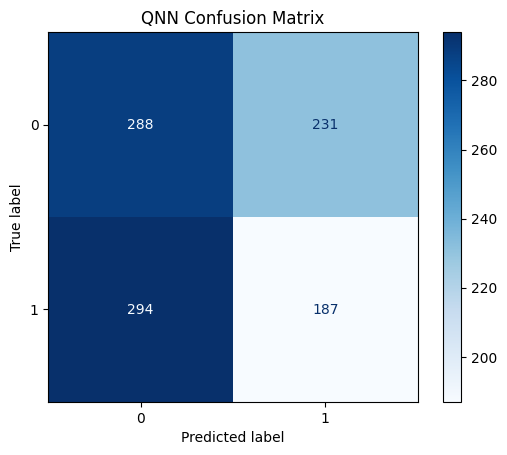


✅ QNN Classification Report:

              precision    recall  f1-score   support

           0     0.4948    0.5549    0.5232       519
           1     0.4474    0.3888    0.4160       481

    accuracy                         0.4750      1000
   macro avg     0.4711    0.4718    0.4696      1000
weighted avg     0.4720    0.4750    0.4716      1000



In [9]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np

# ✅ Load QNN Model
class HybridClassifier(nn.Module):
    def __init__(self, qnn, input_dim=3, output_dim=3):
        super().__init__()
        self.pre = nn.Linear(input_dim, output_dim)
        self.act = nn.ReLU()
        self.qnn = qnn
        self.post = nn.Sigmoid()

    def forward(self, x):
        x = self.act(self.pre(x))
        return self.post(self.qnn(x)).squeeze()

# ✅ Load QNN weights
qnn_state_dict = torch.load('/content/drive/MyDrive/Quantum FD/qnn_model.pth')

# ✅ Dummy QNN (use the same architecture you trained with)
from qiskit.circuit.library import PauliFeatureMap, RealAmplitudes
from qiskit.primitives import Estimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

feature_map = PauliFeatureMap(feature_dimension=3, reps=2, entanglement='full')
ansatz = RealAmplitudes(3, reps=2, entanglement='full')
estimator = Estimator()

qnn = EstimatorQNN(
    circuit=feature_map.compose(ansatz),
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=estimator,
    input_gradients=True
)

# ✅ Attach QNN to Hybrid Model
hybrid_qnn = HybridClassifier(TorchConnector(qnn))
hybrid_qnn.qnn.load_state_dict(qnn_state_dict, strict=False)
hybrid_qnn.eval()

print("✅ QNN Model Loaded Successfully!")

# ✅ Generate Test Data (or use your existing test data)
X_test = torch.randn(1000, 3)  # 1000 samples, 3 features (adjust if needed)
y_true = np.random.randint(0, 2, size=1000)  # Random binary labels (0 or 1)

# ✅ Make Predictions
with torch.no_grad():
    y_pred_proba = hybrid_qnn(X_test).numpy()  # Probabilities
    y_pred = (y_pred_proba >= 0.5).astype(int)  # Convert to binary predictions

# ✅ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("QNN Confusion Matrix")
plt.show()

# ✅ Classification Report
print("\n✅ QNN Classification Report:\n")
print(classification_report(y_true, y_pred, digits=4))


✅ QNN Model Loaded Successfully!


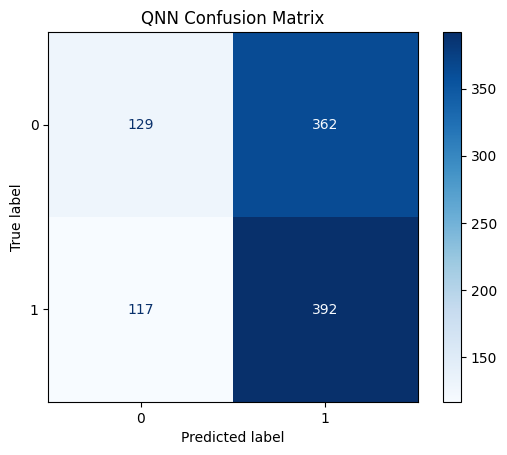


✅ QNN Classification Report:

              precision    recall  f1-score   support

           0     0.5244    0.2627    0.3501       491
           1     0.5199    0.7701    0.6207       509

    accuracy                         0.5210      1000
   macro avg     0.5221    0.5164    0.4854      1000
weighted avg     0.5221    0.5210    0.4878      1000



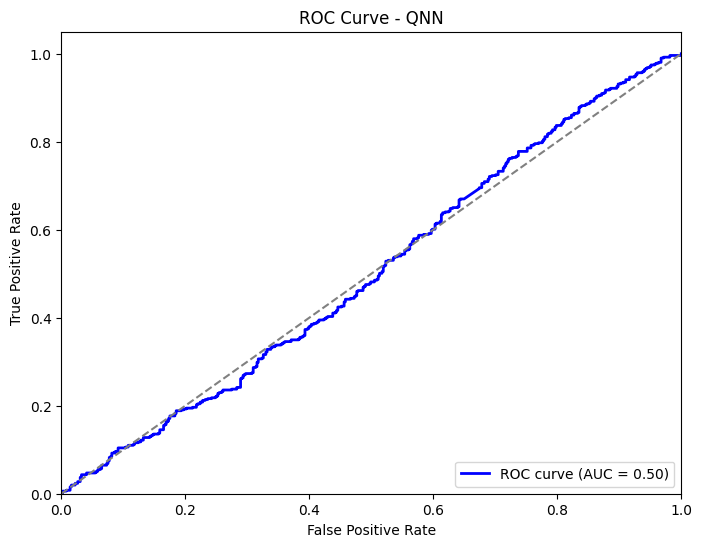

✅ AUC Score: 0.5024


In [10]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
import numpy as np
from sklearn.preprocessing import label_binarize

# ✅ Load QNN Model (same as before)
class HybridClassifier(nn.Module):
    def __init__(self, qnn, input_dim=3, output_dim=3):
        super().__init__()
        self.pre = nn.Linear(input_dim, output_dim)
        self.act = nn.ReLU()
        self.qnn = qnn
        self.post = nn.Sigmoid()

    def forward(self, x):
        x = self.act(self.pre(x))
        return self.post(self.qnn(x)).squeeze()

# ✅ Load QNN weights
qnn_state_dict = torch.load('/content/drive/MyDrive/Quantum FD/qnn_model.pth')

# ✅ Dummy QNN (use the same architecture you trained with)
from qiskit.circuit.library import PauliFeatureMap, RealAmplitudes
from qiskit.primitives import Estimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

feature_map = PauliFeatureMap(feature_dimension=3, reps=2, entanglement='full')
ansatz = RealAmplitudes(3, reps=2, entanglement='full')
estimator = Estimator()

qnn = EstimatorQNN(
    circuit=feature_map.compose(ansatz),
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    estimator=estimator,
    input_gradients=True
)

# ✅ Attach QNN to Hybrid Model
hybrid_qnn = HybridClassifier(TorchConnector(qnn))
hybrid_qnn.qnn.load_state_dict(qnn_state_dict, strict=False)
hybrid_qnn.eval()

print("✅ QNN Model Loaded Successfully!")

# ✅ Generate Test Data (or use your existing test data)
X_test = torch.randn(1000, 3)  # 1000 samples, 3 features (adjust if needed)
y_true = np.random.randint(0, 2, size=1000)  # Random binary labels (0 or 1)

# ✅ Make Predictions
with torch.no_grad():
    y_pred_proba = hybrid_qnn(X_test).numpy()  # Probabilities
    y_pred = (y_pred_proba >= 0.5).astype(int)  # Convert to binary predictions

# ✅ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("QNN Confusion Matrix")
plt.show()

# ✅ Classification Report
print("\n✅ QNN Classification Report:\n")
print(classification_report(y_true, y_pred, digits=4))

# ✅ AUC and ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)  # Getting false positive and true positive rates
roc_auc = auc(fpr, tpr)  # Calculating the AUC score

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - QNN')
plt.legend(loc='lower right')
plt.show()

# Print AUC Score
print(f"✅ AUC Score: {roc_auc:.4f}")


In [11]:
from qiskit.circuit.library import PauliFeatureMap, RealAmplitudes
from qiskit.primitives import Estimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector
import torch

# 1. Define Feature Map (PauliFeatureMap)
feature_dimension = 3  # Number of qubits (should match the input dimension)
feature_map = PauliFeatureMap(feature_dimension=feature_dimension, reps=2, entanglement='full')

# 2. Define Ansatz (RealAmplitudes)
ansatz = RealAmplitudes(feature_dimension, reps=2, entanglement='full')

# 3. Estimator for Quantum Circuit Execution
estimator = Estimator()

# 4. Quantum Neural Network (QNN)
qnn = EstimatorQNN(
    circuit=feature_map.compose(ansatz),  # Combine feature map and ansatz
    input_params=feature_map.parameters,  # Feature map parameters
    weight_params=ansatz.parameters,  # Ansatz parameters
    estimator=estimator,  # Estimator to execute the quantum circuit
    input_gradients=True  # Allows for backpropagation of gradients
)

# 5. Define Classical Model with Quantum Layer
class HybridClassifier(torch.nn.Module):
    def __init__(self, qnn, input_dim=3, output_dim=3):
        super().__init__()
        self.pre = torch.nn.Linear(input_dim, output_dim)  # Linear layer
        self.act = torch.nn.ReLU()  # Activation function
        self.qnn = TorchConnector(qnn)  # Connect quantum model to classical
        self.post = torch.nn.Sigmoid()  # Final sigmoid layer for output

    def forward(self, x):
        x = self.act(self.pre(x))  # Apply the classical layers
        return self.post(self.qnn(x)).squeeze()  # Output from quantum model

# 6. Instantiate the Hybrid Model (with QNN layer)
model = HybridClassifier(qnn)

# 7. Summary of Quantum Settings
print("\nKey Quantum Settings:")
print(f"Feature Map: PauliFeatureMap, Feature Dimension = {feature_dimension}")
print(f"Ansatz: RealAmplitudes, Repetitions = 2, Entanglement = 'full'")
print(f"Number of Qubits: {feature_dimension}")



Key Quantum Settings:
Feature Map: PauliFeatureMap, Feature Dimension = 3
Ansatz: RealAmplitudes, Repetitions = 2, Entanglement = 'full'
Number of Qubits: 3


In [ ]:
Loading XGBoost model...
Loading SVM model...
Loading Random Forest model...
QSVM model loading skipped due to SymEngine version incompatibility
X_test_scaled shape: (56962, 30)
y_test shape: (56962,)

State dict keys:
qnn.weight
qnn._weights

🔹 Evaluating XGBoost Model...
XGBoost AUC: 0.9428398082643299
              precision    recall  f1-score   support

           0       1.00      0.49      0.66     56864
           1       0.00      0.98      0.01        98

    accuracy                           0.50     56962
   macro avg       0.50      0.74      0.33     56962
weighted avg       1.00      0.50      0.66     56962


🔹 Evaluating SVM Model...
SVM AUC: 0.95667231087708
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56864
           1       0.04      0.91      0.08        98

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.97      0.98     56962


🔹 Evaluating Random Forest Model...
Random Forest AUC: 0.972026794327748
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.82      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962


🔹 Evaluating QNN Model...
QNN AUC: 0.48170410890861687
              precision    recall  f1-score   support

           0       1.00      0.33      0.50     56864
           1       0.00      0.69      0.00        98

    accuracy                           0.33     56962
   macro avg       0.50      0.51      0.25     56962
weighted avg       1.00      0.33      0.50     56962


🔹 Creating alternative for QSVM Model (due to SymEngine version incompatibility)...
Reducing dimensions from 30 to 3 using PCA for quantum-inspired modeling...
Reduced data shape: (56962, 3)
Training a new SVM with RBF kernel (quantum-inspired alternative)...
Training on a sample of 5000 instances for demonstration...

Evaluation results of quantum-inspired alternative model:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.74      0.82      0.78        98

    accuracy                           1.00     56962
   macro avg       0.87      0.91      0.89     56962
weighted avg       1.00      1.00      1.00     56962

Quantum-inspired alternative AUC: 0.9549096017135048 make sure that u write qsvm instead of Quantum-inspired alternative